In [1]:
from google.colab import files

uploaded = files.upload()

Saving corrected_medication_logs.csv to corrected_medication_logs.csv


In [2]:
from google.colab import files

uploaded = files.upload()

Saving diet_logs.csv to diet_logs.csv


In [3]:
from google.colab import files

uploaded = files.upload()

Saving workout-logs-month-corrected.csv to workout-logs-month-corrected.csv


In [57]:
from google.colab import files

uploaded = files.upload()

Saving tasks.csv to tasks (1).csv


In [5]:
from google.colab import files

uploaded = files.upload()

Saving symptoms.csv to symptoms.csv


In [6]:
from google.colab import files

uploaded = files.upload()

Saving patients.csv to patients.csv


In [7]:
from google.colab import files

uploaded = files.upload()

Saving patient_metrics.csv to patient_metrics.csv


In [59]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
med_logs = pd.read_csv('corrected_medication_logs.csv', parse_dates=['scheduled_time', 'taken_time', 'logged_at'])
diet_logs = pd.read_csv('diet_logs.csv')
workout_logs = pd.read_csv('workout-logs-month-corrected.csv')
tasks = pd.read_csv('tasks (1).csv')
symptoms = pd.read_csv('symptoms.csv')
patients = pd.read_csv('patients.csv')
patient_metrics = pd.read_csv('patient_metrics.csv')

In [61]:
# --- PREPROCESS DATES ---
diet_logs['date'] = pd.to_datetime(diet_logs['date'], format='%d-%m-%Y', errors='coerce')
workout_logs['date'] = pd.to_datetime(workout_logs['date'], format='%d-%m-%Y', errors='coerce')


In [62]:
 #--- FEATURE ENGINEERING ---

# Medication adherence
med_logs['taken_flag'] = med_logs['status'] == 'taken'
med_agg = med_logs.groupby('patientId').agg(
    med_taken_pct=('taken_flag', 'mean'),
    missed_doses=('taken_flag', lambda x: (~x).sum()),
    severe_side_effects=('side_effects__severity', lambda x: pd.to_numeric(x, errors='coerce').ge(3).sum())
).reset_index()

# Diet adherence
diet_logs['consumed_flag'] = diet_logs['status'] == 'consumed'
diet_agg = diet_logs.groupby('patientId').agg(
    diet_consumed_pct=('consumed_flag', 'mean'),
    skipped_meals=('consumed_flag', lambda x: (~x).sum())
).reset_index()

# Workout adherence
workout_logs['completed_flag'] = workout_logs['status'] == 'completed'
workout_agg = workout_logs.groupby('patientId').agg(
    workout_completed_pct=('completed_flag', 'mean'),
    missed_workouts=('completed_flag', lambda x: (~x).sum())
).reset_index()

# Task adherence
tasks['completed_flag'] = tasks['status'] == 'completed'
task_agg = tasks.groupby('assignedTo').agg(
    task_completed_pct=('completed_flag', 'mean'),
    pending_tasks=('completed_flag', lambda x: (~x).sum())
).reset_index().rename(columns={'assignedTo': 'patientId'})

# Symptom severity
severity_map = {'mild': 1, 'moderate': 2, 'severe': 3}
symptoms['severity_num'] = symptoms['severity'].map(severity_map)
symptom_agg = symptoms.groupby('patientId').agg(
    symptom_severity_sum=('severity_num', 'sum'),
    symptom_count=('severity_num', 'count')
).reset_index()


In [64]:
# --- MERGE ALL FEATURES ---
features = med_agg.merge(diet_agg, on='patientId', how='outer')
features = features.merge(workout_agg, on='patientId', how='outer')
features = features.merge(task_agg, on='patientId', how='outer')
features = features.merge(symptom_agg, on='patientId', how='outer')
features.fillna(0, inplace=True)

In [65]:
# --- DEFINE TARGET ---
if patient_metrics is not None:
    patient_metrics['high_risk'] = patient_metrics['totalRisk'] > 3.0
    features = features.merge(patient_metrics[['patientId', 'high_risk']], on='patientId', how='left')
    features['high_risk'].fillna(False, inplace=True)
    y = features['high_risk'].astype(int)
else:
    # Dummy target for demonstration
    y = (features['missed_doses'] + features['missed_workouts'] + features['skipped_meals']) > 5

X = features.drop(columns=['patientId', 'high_risk'] if 'high_risk' in features.columns else ['patientId'])

<ipython-input-65-53857c6699cd>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  features['high_risk'].fillna(False, inplace=True)


In [66]:
# --- MODEL TRAINING ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))




              precision    recall  f1-score   support

           0       0.82      1.00      0.90         9
           1       1.00      0.33      0.50         3

    accuracy                           0.83        12
   macro avg       0.91      0.67      0.70        12
weighted avg       0.86      0.83      0.80        12



In [67]:
!pip install imbalanced-learn

In [68]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np # Import numpy to use np.unique

# Assume X, y are already prepared as in your previous pipeline

# Stratified split to maintain class proportions in test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Check the class distribution in the training set
class_counts = y_train.value_counts()
print("Class distribution before SMOTE:", class_counts)

# Determine the minimum number of samples in any class
min_samples = class_counts.min()

# Set k_neighbors for SMOTE. It must be less than the minimum class size.
# A safe choice is min_samples - 1, but ensure it's at least 1.
# If min_samples is 1, SMOTE with any k_neighbors > 0 will fail.
# Consider handling extremely rare classes separately if min_samples is very small.
# For this fix, let's assume min_samples > 1 and set k_neighbors = min_samples - 1.
# If min_samples is 1, SMOTE cannot be applied to that class with default settings.
# We'll add a check.
if min_samples <= 1:
    print("Warning: Smallest class has 1 or fewer samples. SMOTE cannot be applied effectively to this class.")
    # Option 1: Skip SMOTE or handle this class manually
    # Option 2: Proceed with a small k_neighbors if min_samples > 1, but be aware of potential issues.
    # For now, let's set k_neighbors to a safe value if possible, otherwise default might raise error.
    k_neighbors_smote = 1 if min_samples > 1 else 0 # SMOTE requires k_neighbors >= 1

else:
    k_neighbors_smote = min_samples - 1

# Apply SMOTE only on the training data, with adjusted k_neighbors
# Only apply SMOTE if there's a minority class with more than 1 sample and majority class.
if len(class_counts) > 1 and min_samples > 1:
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors_smote)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print("Class distribution after SMOTE:", dict(zip(*np.unique(y_train_res, return_counts=True))))
else:
     print("SMOTE not applied: Not enough samples in minority class or only one class present.")
     X_train_res, y_train_res = X_train, y_train


# Train the classifier (Random Forest, but you can try others)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_res, y_train_res)

# Predict and evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Class distribution before SMOTE: high_risk
0    24
1     4
Name: count, dtype: int64
Class distribution after SMOTE: {np.int64(0): np.int64(24), np.int64(1): np.int64(24)}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         1

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12

Confusion matrix:
 [[11  0]
 [ 0  1]]


In [69]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=skf, scoring='f1')
print("Mean F1 score (cross-validated):", scores.mean())


Mean F1 score (cross-validated): 0.4


In [70]:
# Example: Flag as high risk if missed > 3 doses or any severe side effect
features['rule_high_risk'] = ((features['missed_doses'] > 3) | (features['severe_side_effects'] > 0)).astype(int)
print(features[['patientId', 'missed_doses', 'severe_side_effects', 'rule_high_risk']])


   patientId  missed_doses  severe_side_effects  rule_high_risk
0       pat1             6                    6               1
1      pat10             5                    3               1
2      pat11             4                   11               1
3      pat12             6                    3               1
4      pat13             5                    1               1
5      pat14             6                    8               1
6      pat15             5                    3               1
7      pat16             4                    2               1
8      pat17             5                    5               1
9      pat18             6                    3               1
10     pat19             7                    2               1
11      pat2             8                    4               1
12     pat20             8                    7               1
13     pat21             5                    3               1
14     pat22             2              

In [71]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       0.00      0.00      0.00         1

    accuracy                           0.92        12
   macro avg       0.46      0.50      0.48        12
weighted avg       0.84      0.92      0.88        12



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [72]:
# Flag as at-risk of drop-off if more than 3 missed medication doses in 2 weeks
patient_metrics['drop_off_risk'] = (patient_metrics['missedDoses'] > 3) | \
                                   (patient_metrics['tasks_adheranceScore'] < 30) | \
                                   (patient_metrics['workouts_adheranceScore'] < 30)


In [73]:
# Merge all features
features = med_agg.merge(diet_agg, on='patientId', how='outer')
features = features.merge(workout_agg, on='patientId', how='outer')
features = features.merge(task_agg, on='patientId', how='outer')
features = features.merge(symptom_agg, on='patientId', how='outer')
features = features.merge(patients[['patientId', 'patient_name']], on='patientId', how='left')
features.fillna(0, inplace=True)


<Figure size 640x480 with 0 Axes>

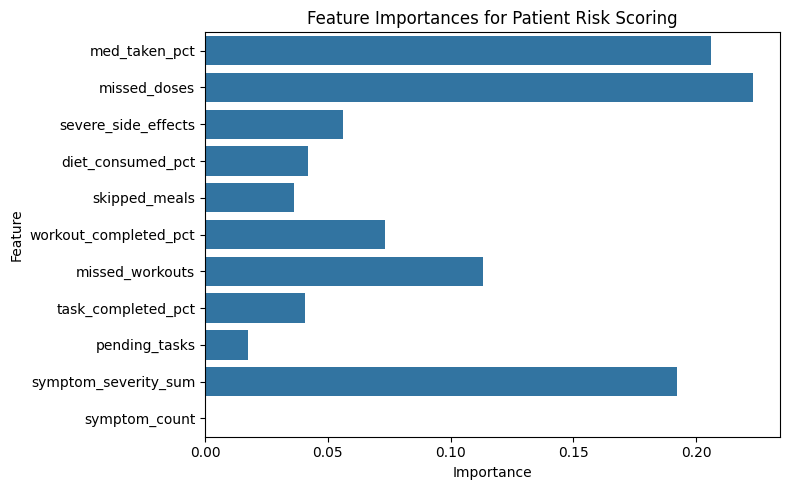

<Figure size 640x480 with 0 Axes>

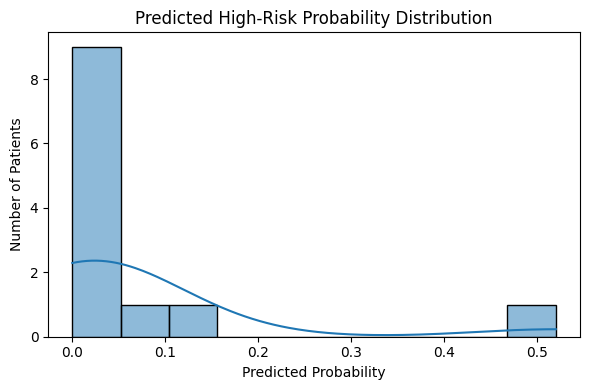

<Figure size 640x480 with 0 Axes>

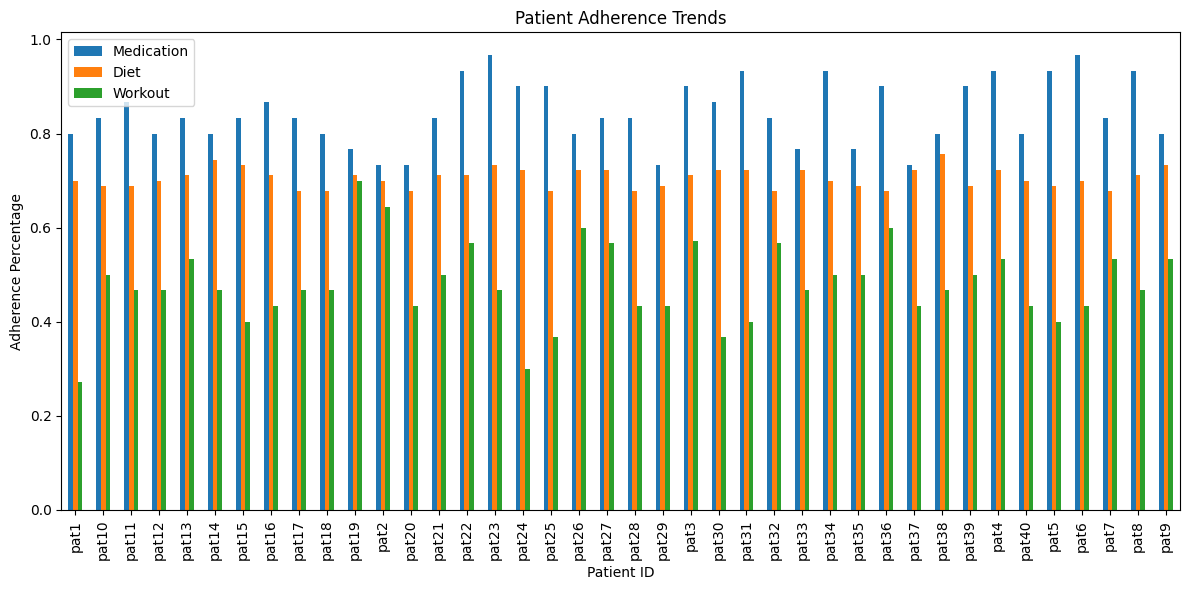

<Figure size 640x480 with 0 Axes>

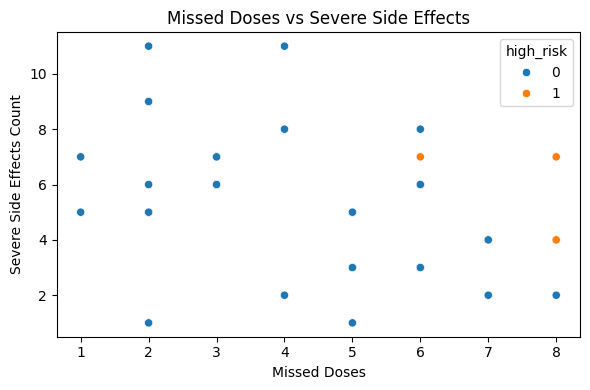

<Figure size 640x480 with 0 Axes>

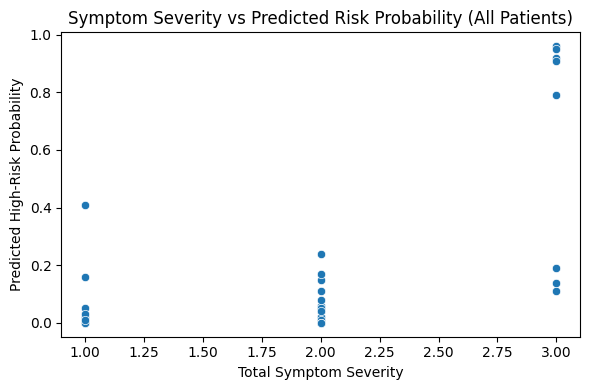

In [74]:
# --- VISUALIZATIONS ---

# 1. Feature Importance Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title('Feature Importances for Patient Risk Scoring')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
plt.savefig('feature_importance.png')

# 2. Risk Probability Distribution
plt.figure(figsize=(6, 4))
sns.histplot(y_proba, bins=10, kde=True)
plt.title('Predicted High-Risk Probability Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()
plt.savefig('risk_probability_distribution.png')

# 3. Adherence Trends (Medication, Diet, Workout)
adherence_df = features[['patientId', 'med_taken_pct', 'diet_consumed_pct', 'workout_completed_pct']]
adherence_df = adherence_df.set_index('patientId')
adherence_df.plot(kind='bar', figsize=(12, 6))
plt.title('Patient Adherence Trends')
plt.xlabel('Patient ID')
plt.ylabel('Adherence Percentage')
plt.legend(['Medication', 'Diet', 'Workout'])
plt.tight_layout()
plt.show()
plt.savefig('adherence_trends.png')

# 4. Severe Side Effects vs Missed Doses
plt.figure(figsize=(6, 4))
sns.scatterplot(x=features['missed_doses'], y=features['severe_side_effects'], hue=y)
plt.title('Missed Doses vs Severe Side Effects')
plt.xlabel('Missed Doses')
plt.ylabel('Severe Side Effects Count')
plt.tight_layout()
plt.show()
plt.savefig('side_effects_vs_missed_doses.png')
# 5. Symptom Severity vs Risk Probability (using probabilities for the whole dataset)
y_proba_all = clf.predict_proba(X)[:, 1]
plt.figure(figsize=(6, 4))
sns.scatterplot(x=features['symptom_severity_sum'], y=y_proba_all) # Use y_proba_all here
plt.title('Symptom Severity vs Predicted Risk Probability (All Patients)')
plt.xlabel('Total Symptom Severity')
plt.ylabel('Predicted High-Risk Probability')
plt.tight_layout()
plt.show()
plt.savefig('symptom_severity_vs_risk.png')

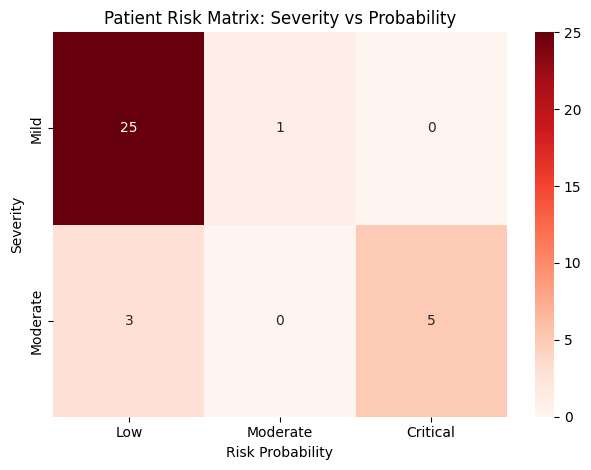

In [75]:
# Example: Assume features['risk_probability'] and features['symptom_severity_sum'] exist
# First, calculate the risk probability for all patients using the trained classifier (clf)
y_proba_all = clf.predict_proba(X)[:, 1]

# Add the predicted risk probability as a new column to the features DataFrame
features['risk_probability'] = y_proba_all

# Now, proceed with creating the risk_matrix using the new 'risk_probability' column
risk_matrix = pd.DataFrame({
    'Risk Probability': pd.cut(features['risk_probability'], bins=[0,0.25,0.5,0.75,1.0], labels=['Low','Moderate','High','Critical']),
    'Severity': pd.cut(features['symptom_severity_sum'], bins=[-1,2,5,8,100], labels=['Mild','Moderate','Severe','Very Severe'])
})
matrix = pd.crosstab(risk_matrix['Severity'], risk_matrix['Risk Probability'])
sns.heatmap(matrix, annot=True, cmap='Reds')
plt.title('Patient Risk Matrix: Severity vs Probability')
plt.tight_layout()
plt.show()
plt.savefig('risk_matrix.png')

<Figure size 640x480 with 0 Axes>

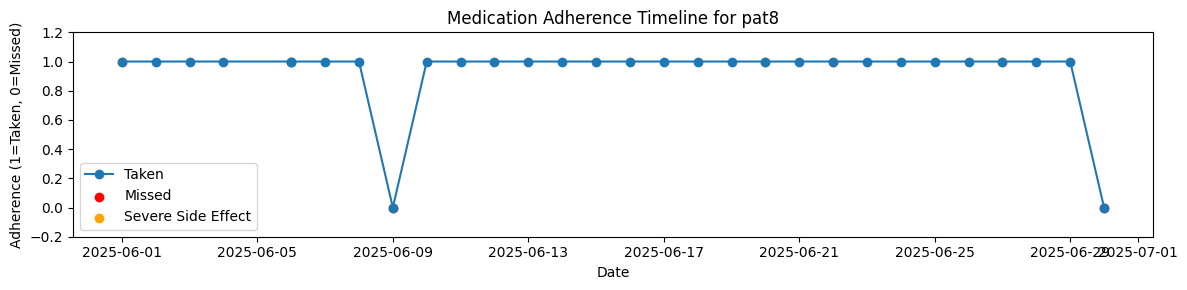

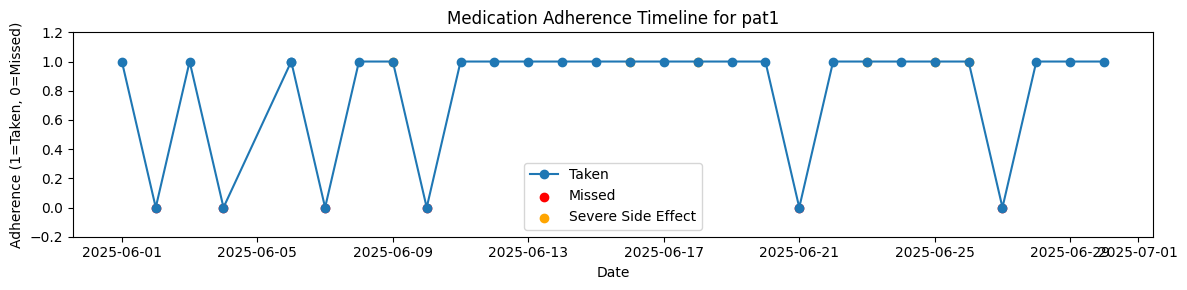

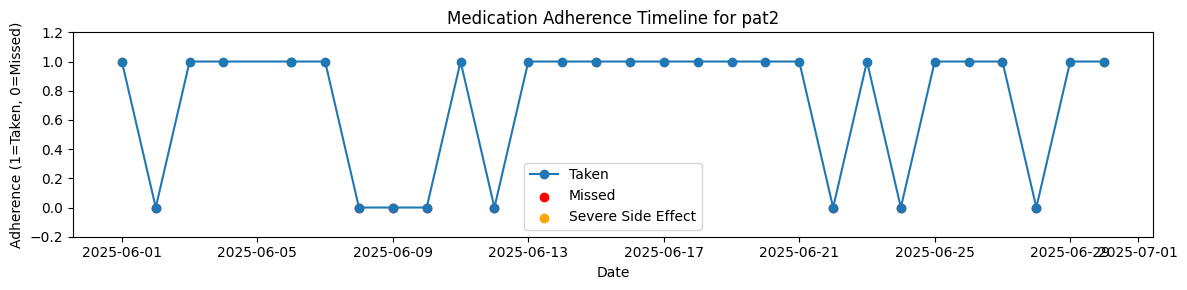

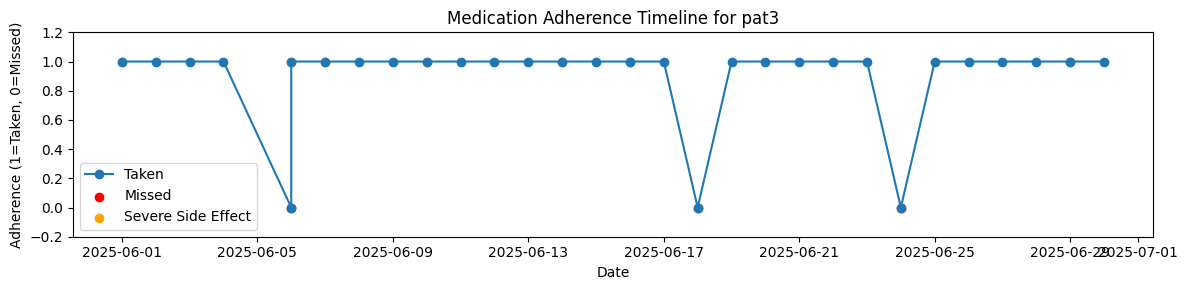

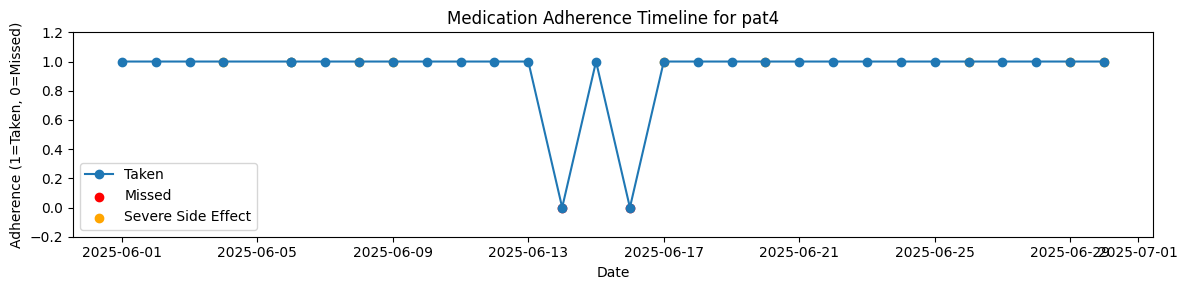

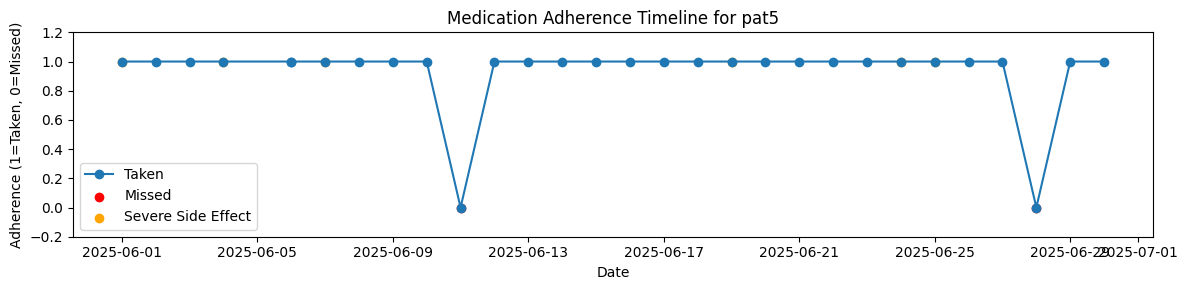

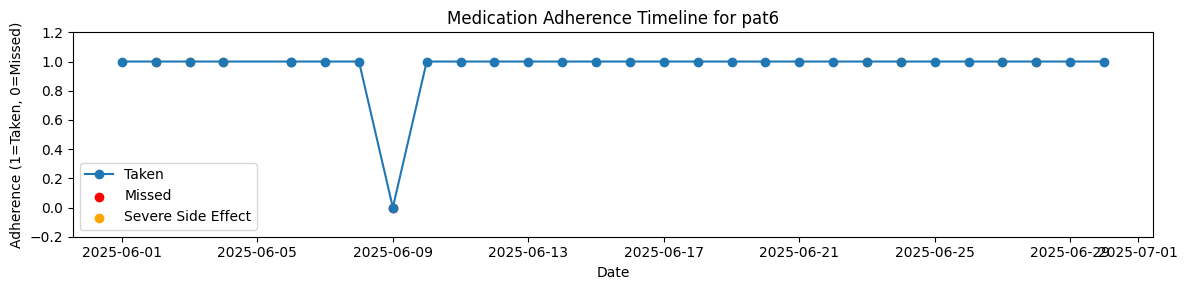

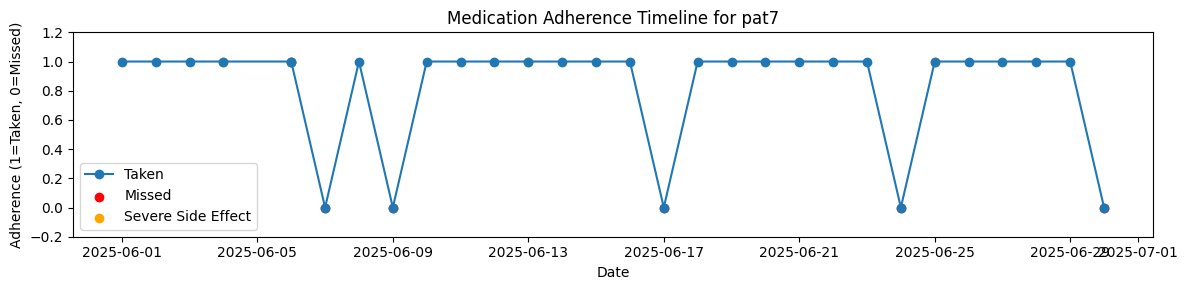

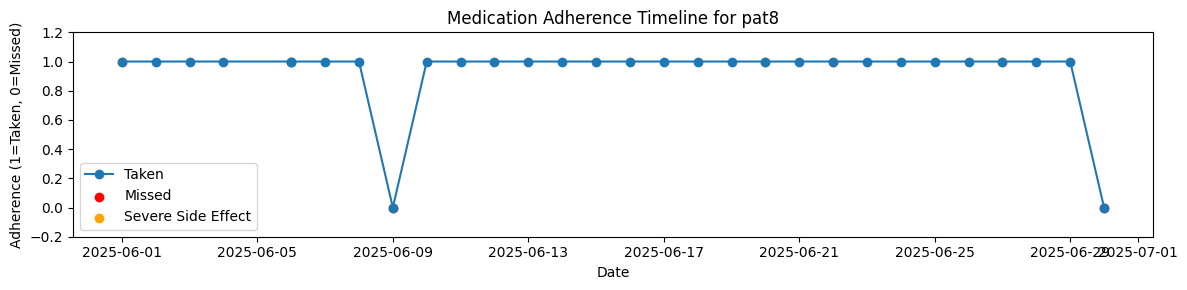

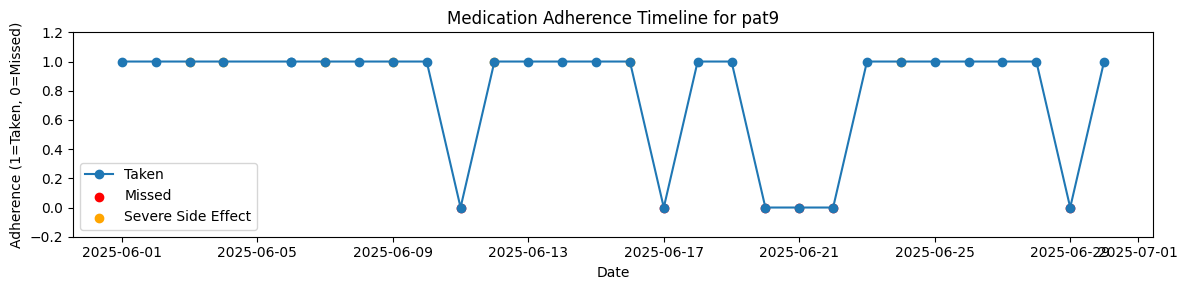

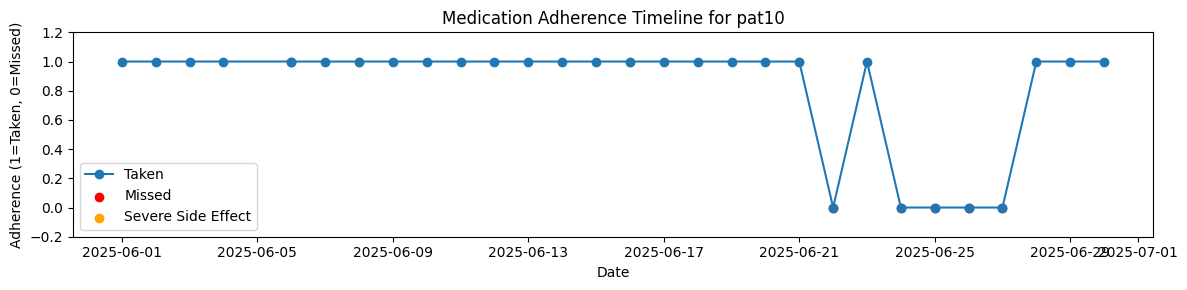

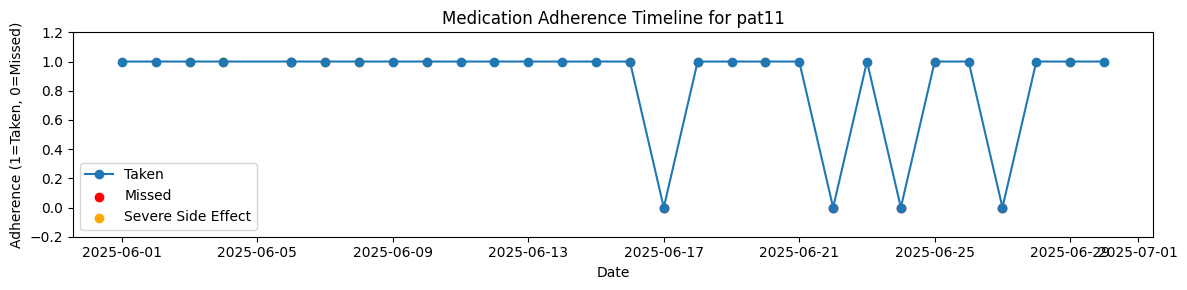

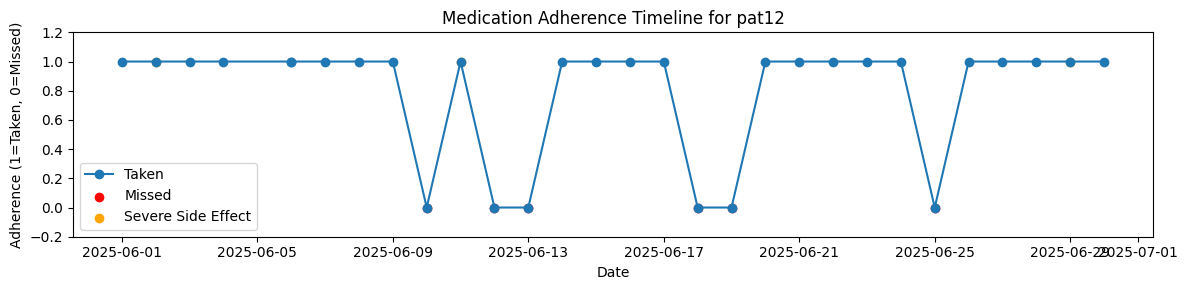

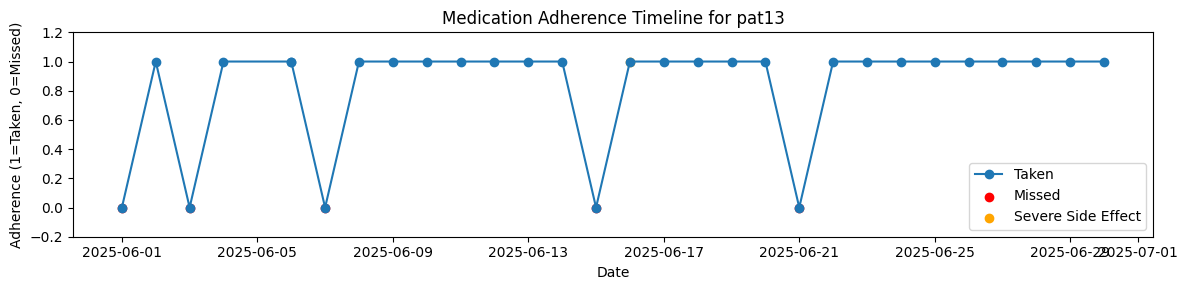

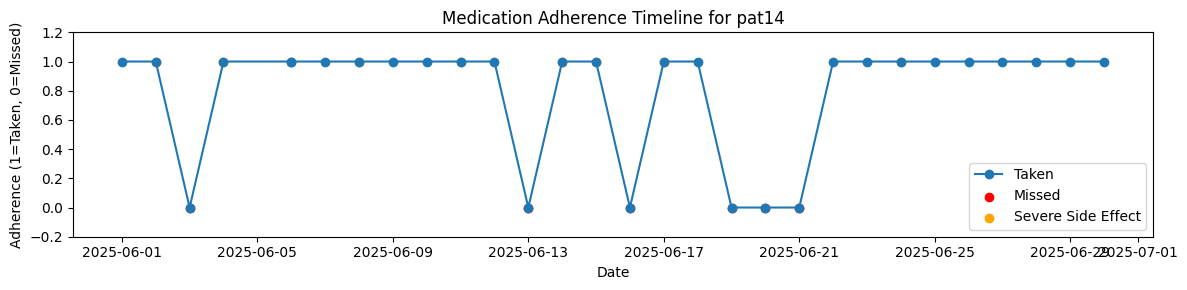

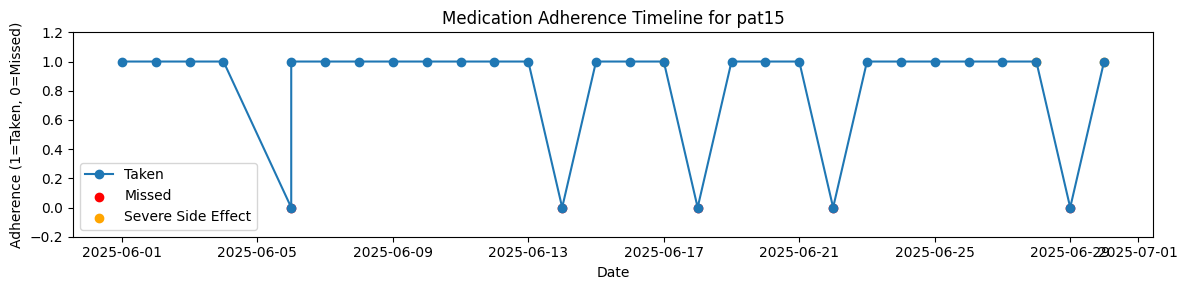

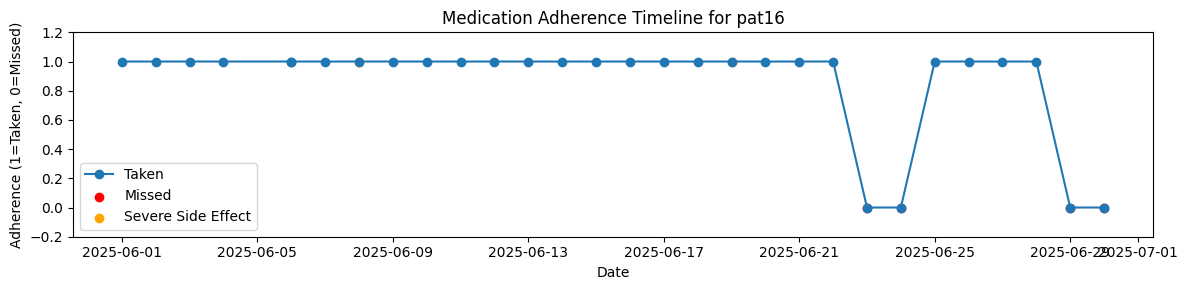

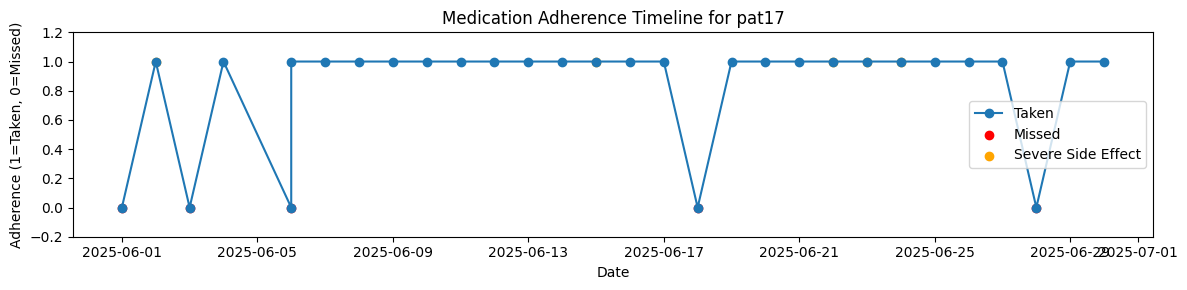

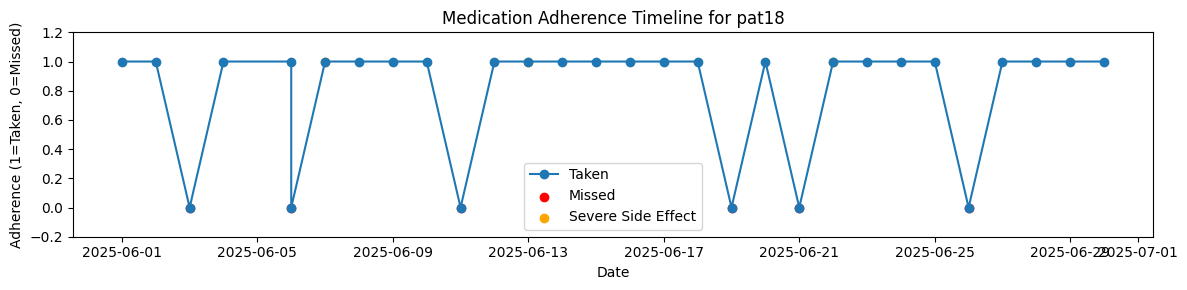

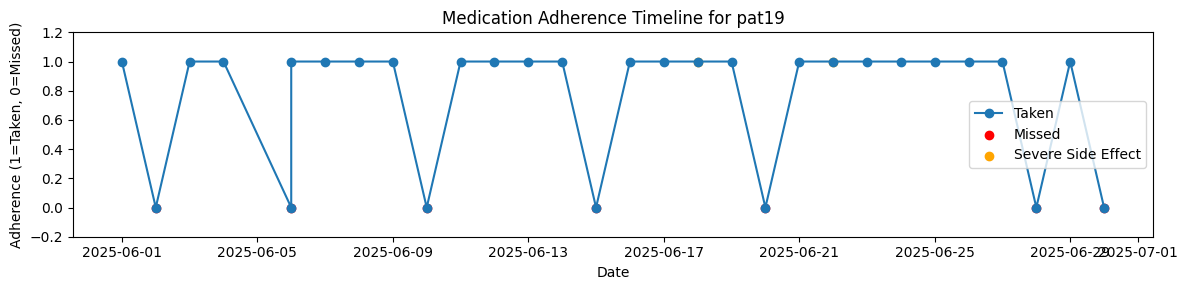

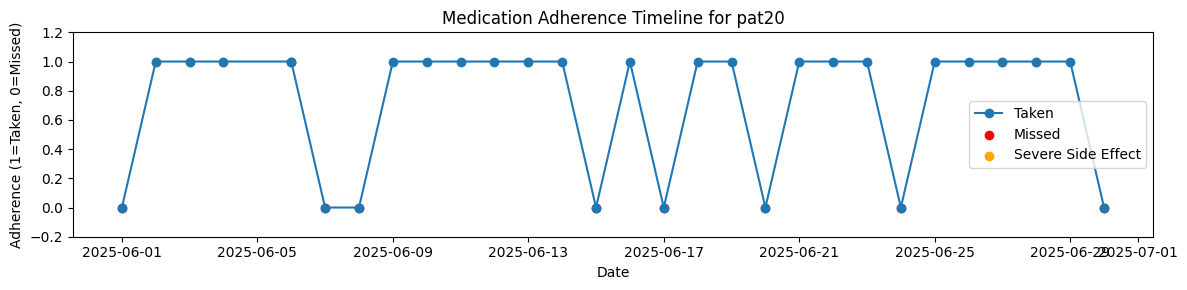

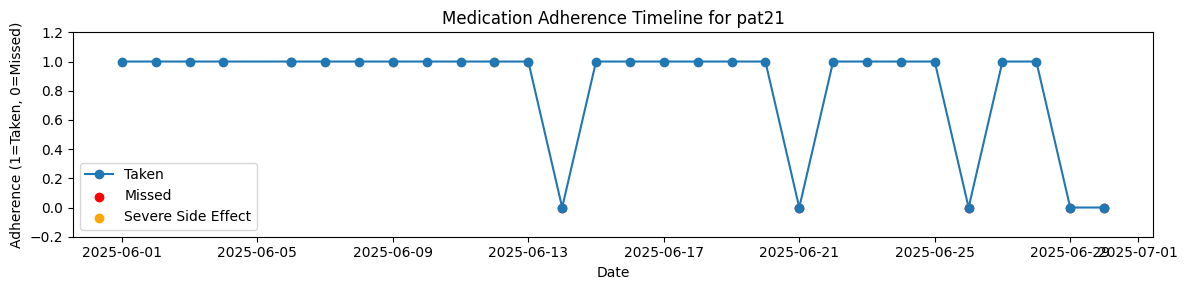

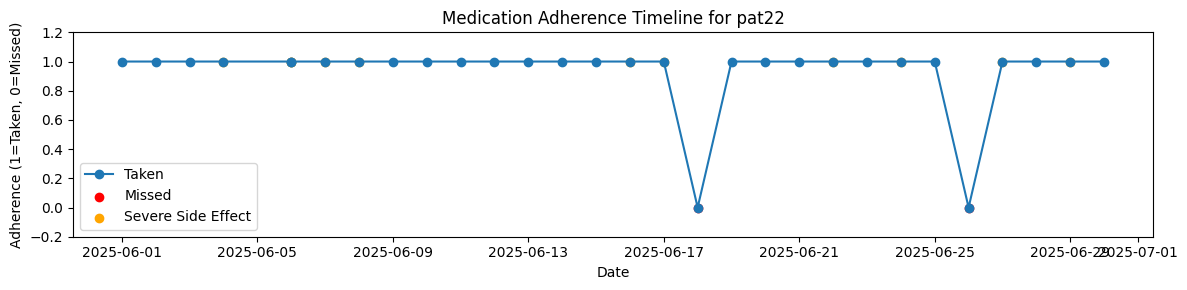

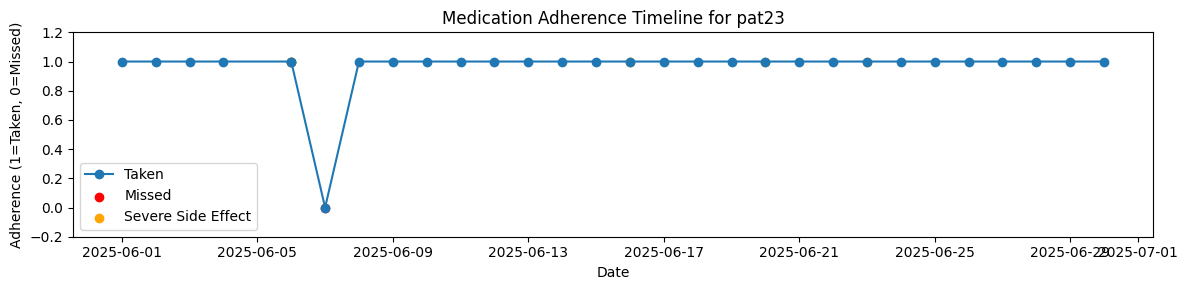

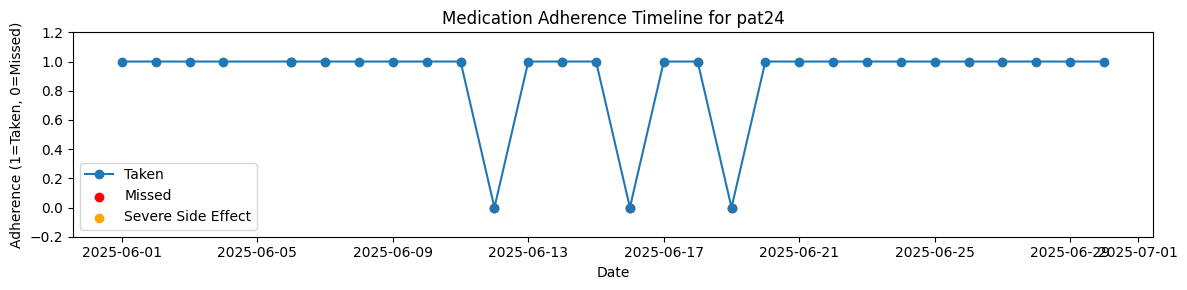

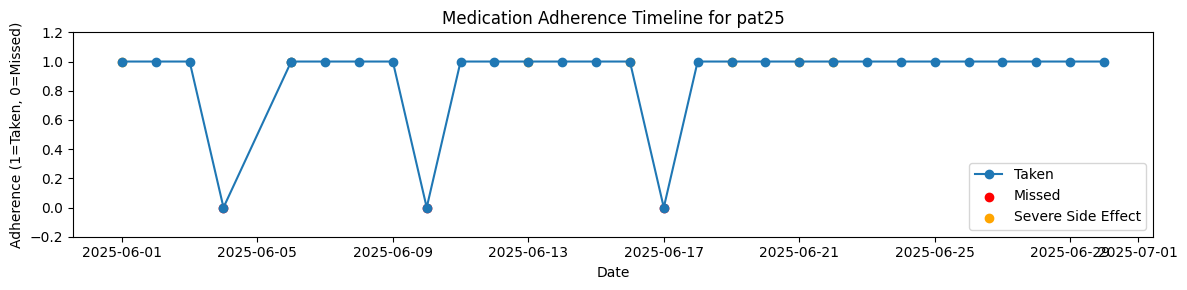

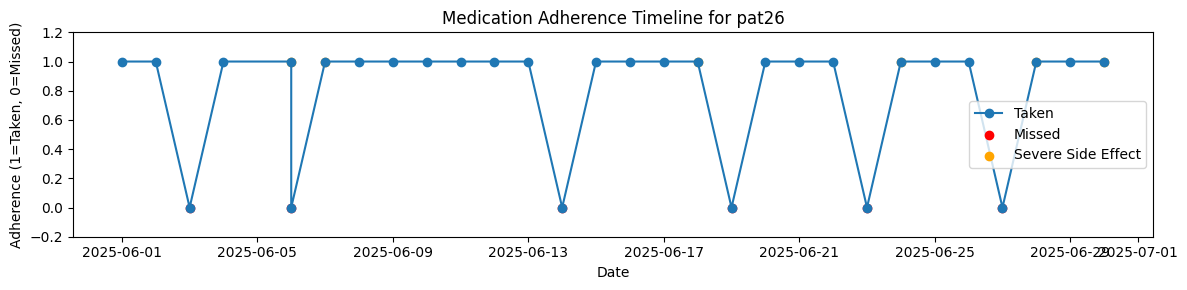

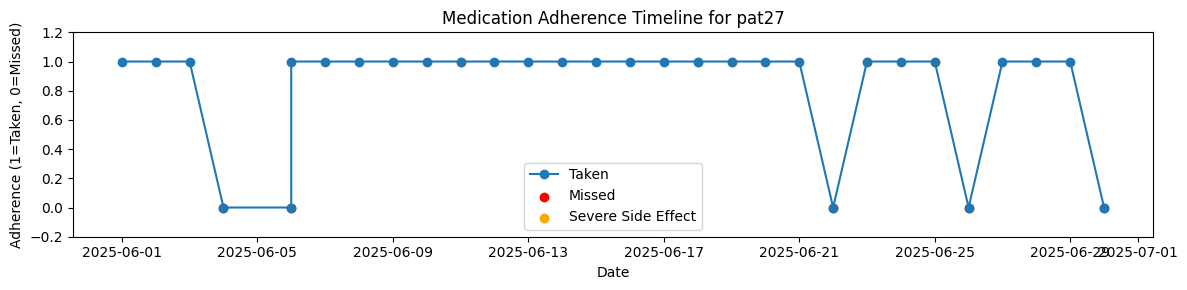

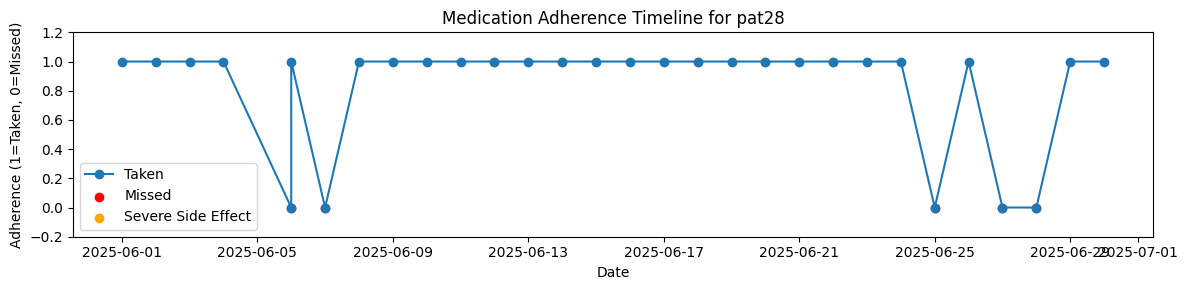

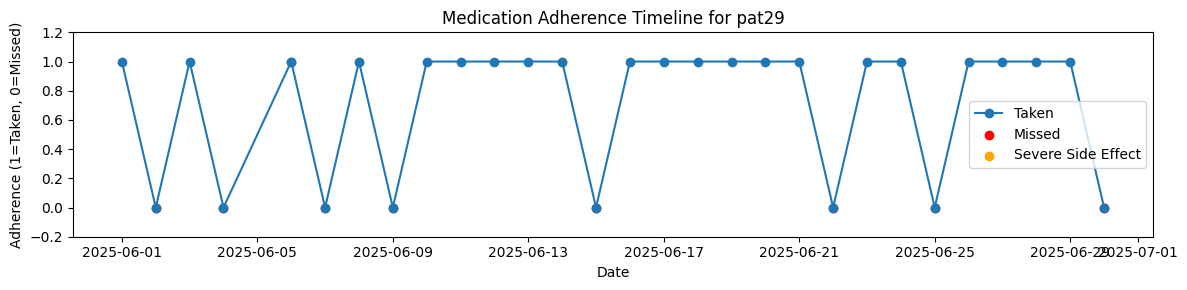

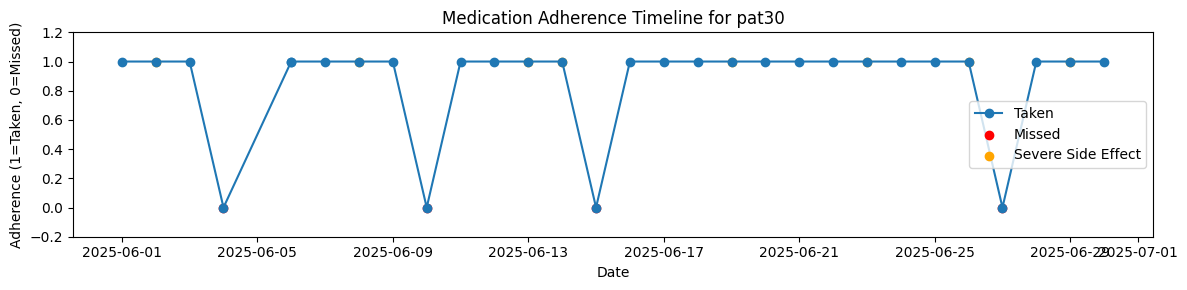

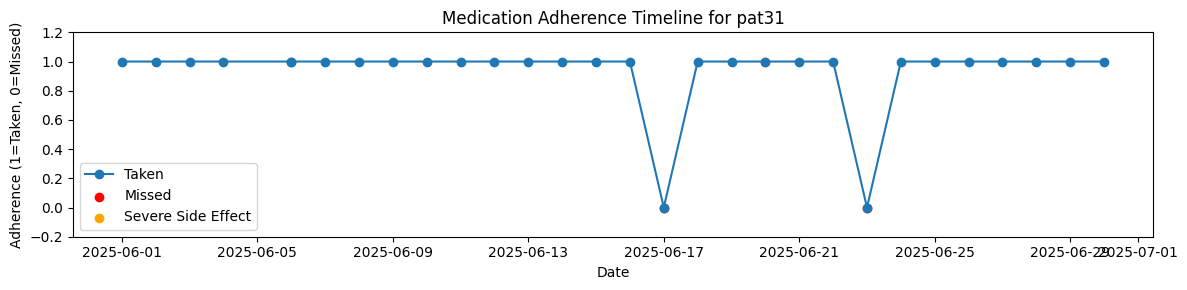

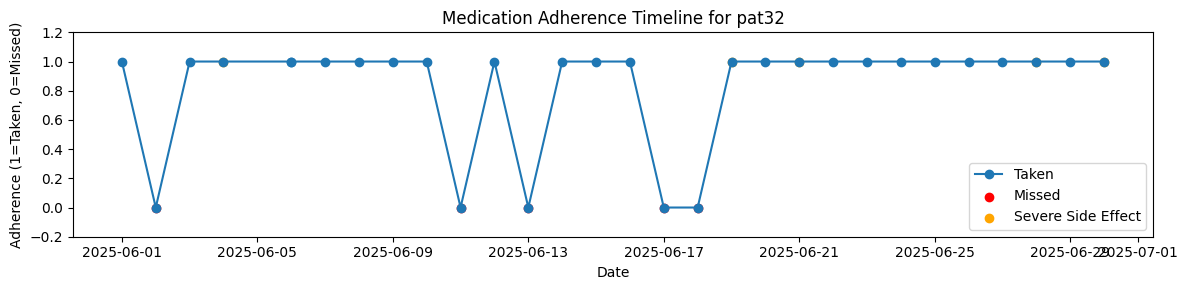

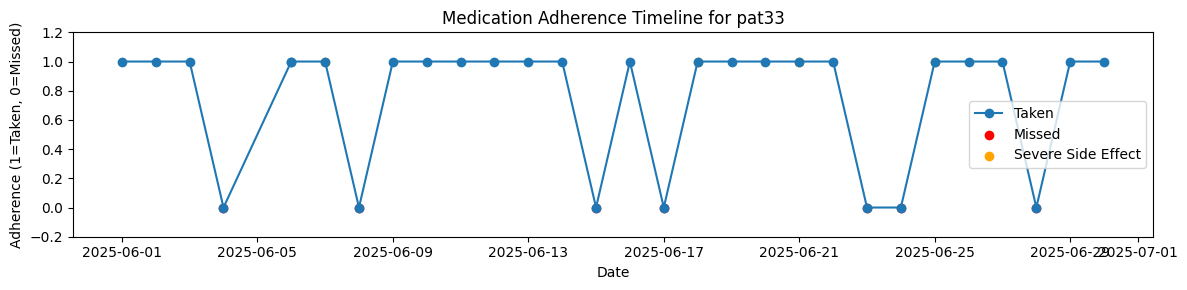

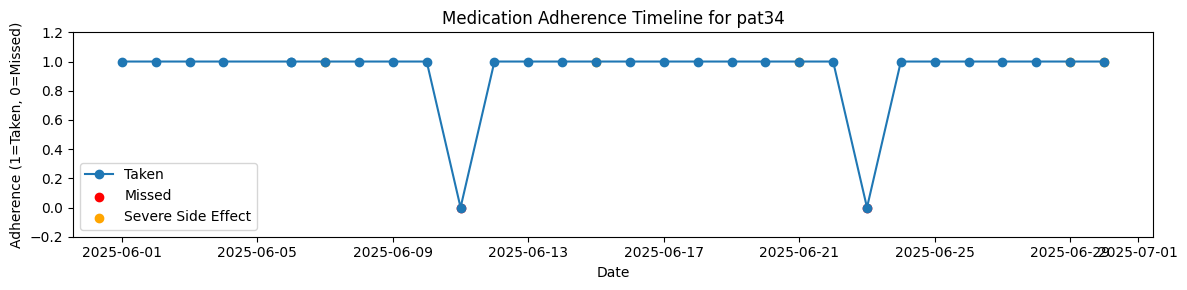

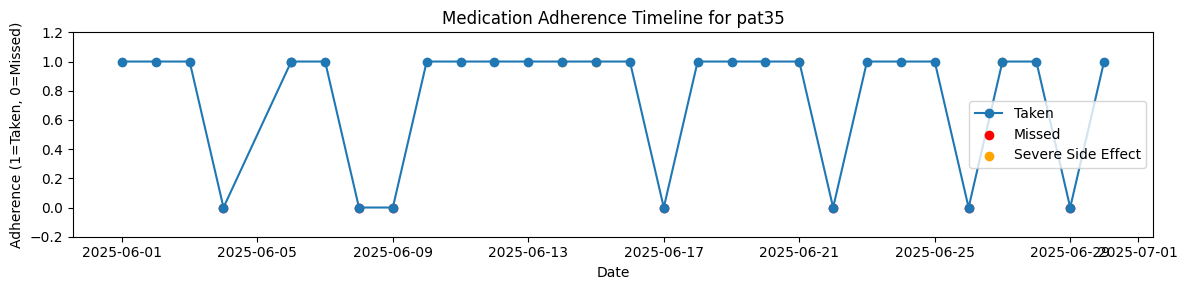

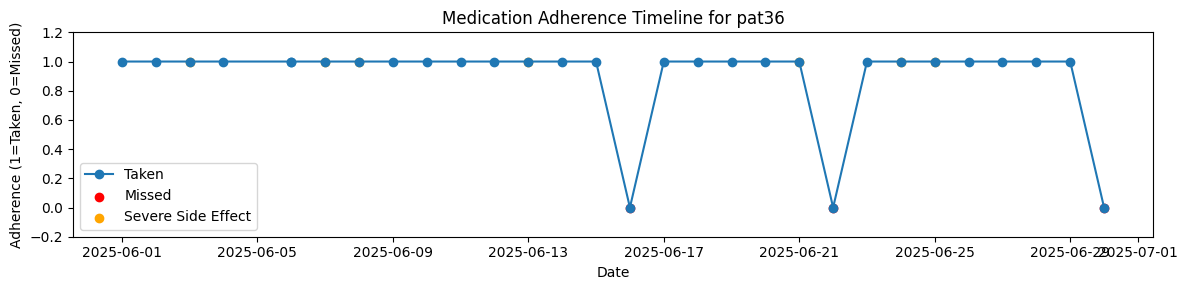

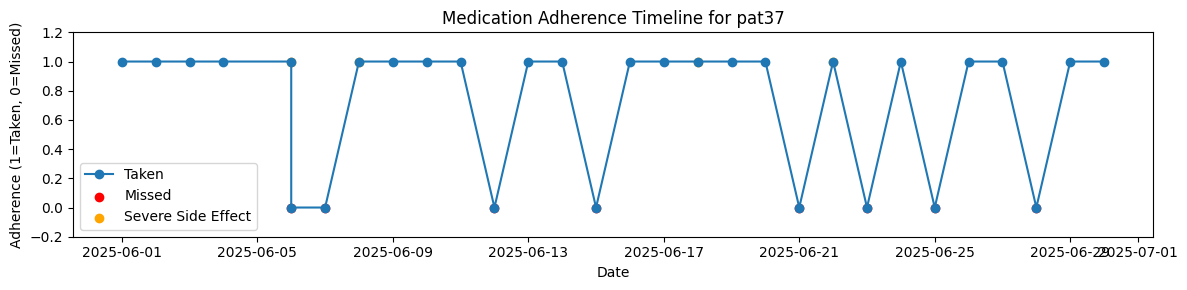

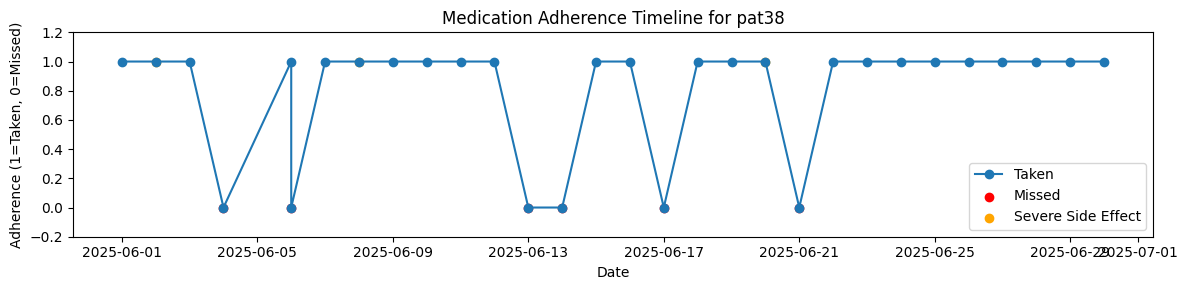

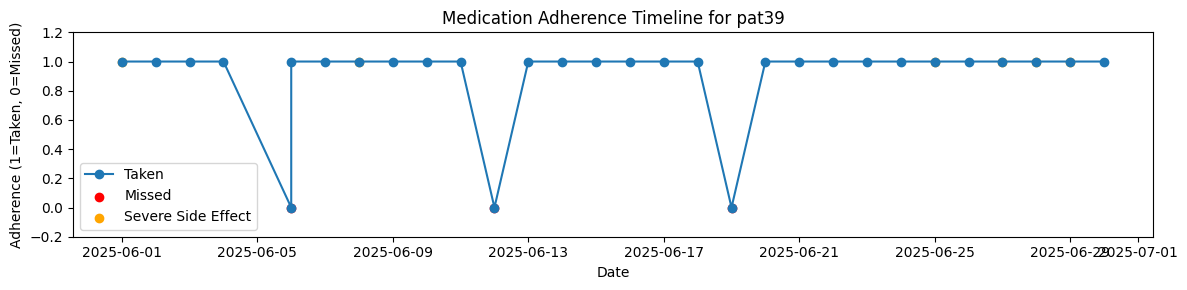

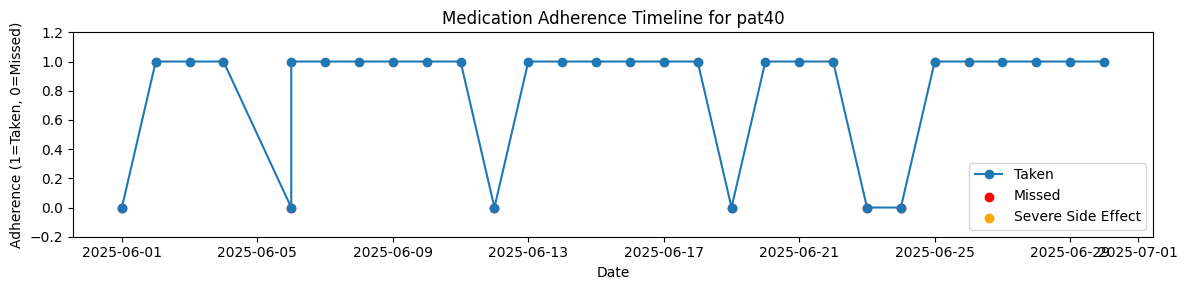

'Generated medication adherence timeline plots for all patients.'

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load medication logs
med_logs = pd.read_csv('corrected_medication_logs.csv')

# Get unique patient IDs
patient_ids = med_logs['patientId'].unique()

# Create adherence timeline plots for all patients
for pid in patient_ids:
    med_logs_pat = med_logs[med_logs['patientId'] == pid].copy()
    med_logs_pat['date'] = pd.to_datetime(med_logs_pat['scheduled_time']).dt.date
    med_logs_pat['adherence'] = np.where(med_logs_pat['status']=='taken', 1, 0)
    plt.figure(figsize=(12,3))
    plt.plot(med_logs_pat['date'], med_logs_pat['adherence'], marker='o', label='Taken')
    plt.scatter(med_logs_pat.loc[med_logs_pat['status']=='missed', 'date'], [0]*sum(med_logs_pat['status']=='missed'), color='red', label='Missed')
    plt.scatter(med_logs_pat.loc[pd.to_numeric(med_logs_pat['side_effects__severity'], errors='coerce')>=3, 'date'], [1]*sum(pd.to_numeric(med_logs_pat['side_effects__severity'], errors='coerce')>=3), color='orange', label='Severe Side Effect')
    plt.ylim(-0.2,1.2)
    plt.title(f'Medication Adherence Timeline for {pid}')
    plt.xlabel('Date')
    plt.ylabel('Adherence (1=Taken, 0=Missed)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.savefig(f'med_adherence_timeline_{pid}.png')
    plt.close()

"Generated medication adherence timeline plots for all patients."


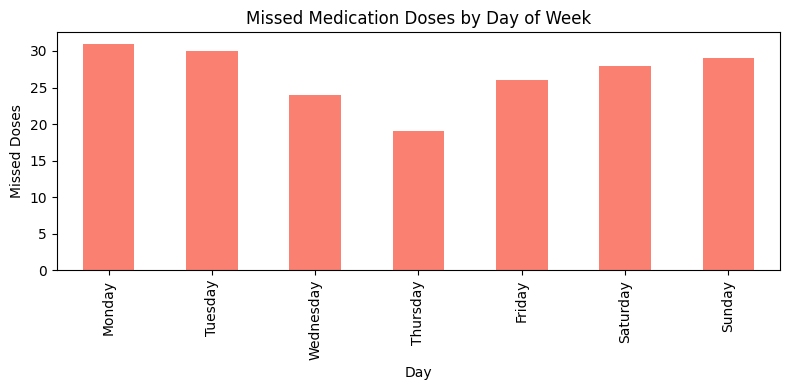

<Figure size 640x480 with 0 Axes>

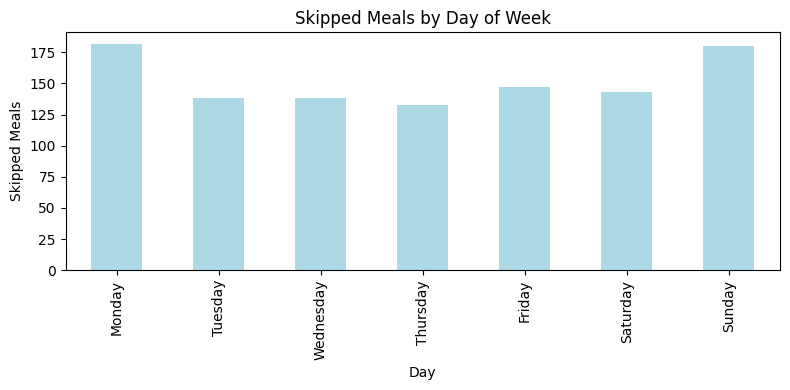

In [80]:
# Medication
med_logs['weekday'] = pd.to_datetime(med_logs['scheduled_time']).dt.day_name()
missed_by_day = med_logs[med_logs['status']=='missed'].groupby('weekday').size().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.figure(figsize=(8,4))
missed_by_day.plot(kind='bar', color='salmon')
plt.title('Missed Medication Doses by Day of Week')
plt.xlabel('Day')
plt.ylabel('Missed Doses')
plt.tight_layout()
plt.show()
plt.savefig('missed_doses_by_day.png')
# Diet
diet_logs['weekday'] = pd.to_datetime(diet_logs['date'], format='%d-%m-%Y').dt.day_name()
skipped_by_day = diet_logs[diet_logs['status']=='skipped'].groupby('weekday').size().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.figure(figsize=(8,4))
skipped_by_day.plot(kind='bar', color='lightblue')
plt.title('Skipped Meals by Day of Week')
plt.xlabel('Day')
plt.ylabel('Skipped Meals')
plt.tight_layout()
plt.show()
plt.savefig('skipped_meals_by_day.png')


<ipython-input-81-1b68bccd92ba>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='risk_probability', y='patientId', data=top_risk, palette='Reds_r')


<Figure size 640x480 with 0 Axes>

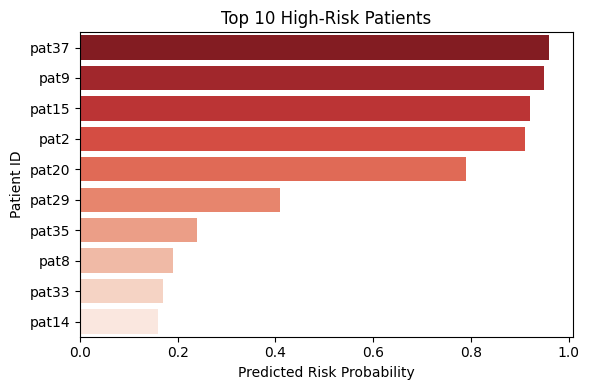

In [81]:
# Top 10 patients by risk probability
top_risk = features[['patientId','risk_probability']].sort_values('risk_probability', ascending=False).head(10)
plt.figure(figsize=(6,4))
sns.barplot(x='risk_probability', y='patientId', data=top_risk, palette='Reds_r')
plt.title('Top 10 High-Risk Patients')
plt.xlabel('Predicted Risk Probability')
plt.ylabel('Patient ID')
plt.tight_layout()
plt.show()
plt.savefig('risk_leaderboard.png')


<Figure size 640x480 with 0 Axes>

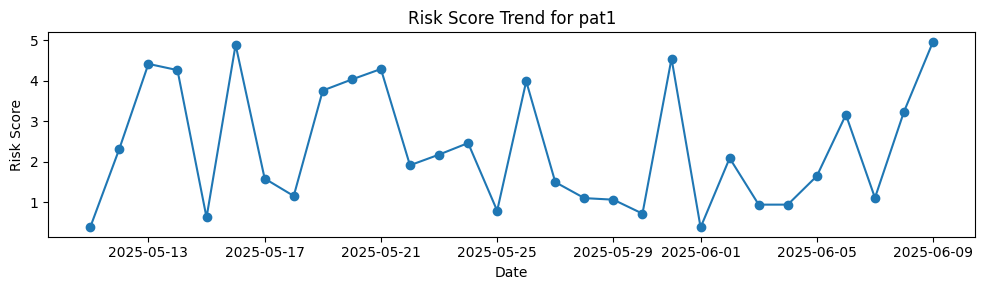

<Figure size 640x480 with 0 Axes>

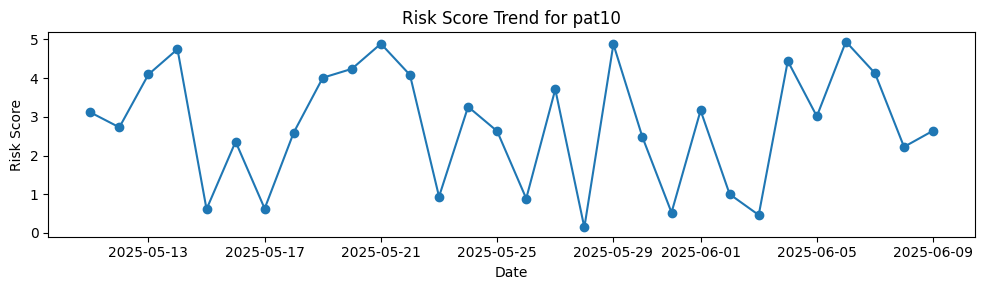

<Figure size 640x480 with 0 Axes>

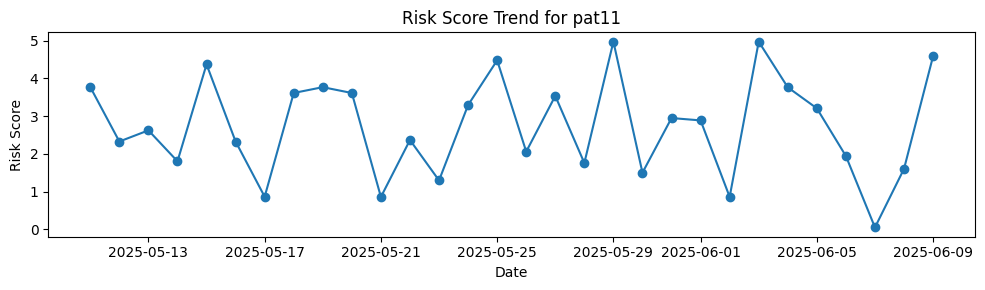

<Figure size 640x480 with 0 Axes>

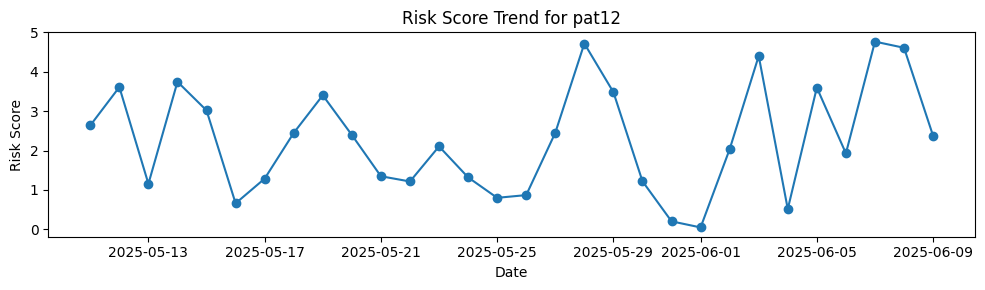

<Figure size 640x480 with 0 Axes>

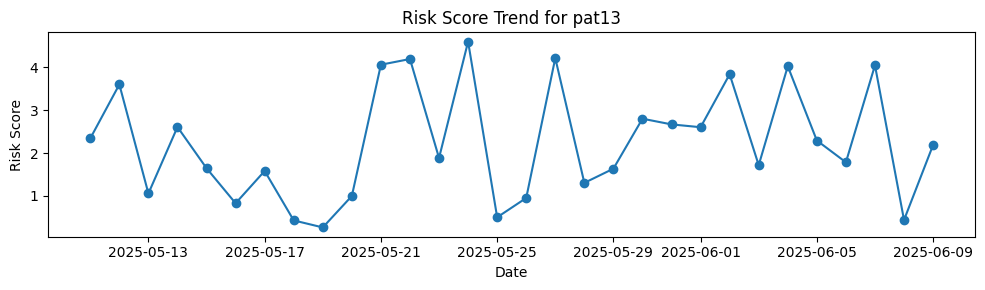

<Figure size 640x480 with 0 Axes>

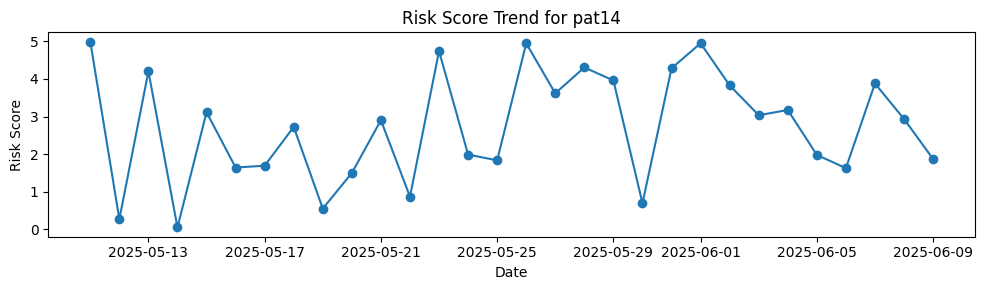

<Figure size 640x480 with 0 Axes>

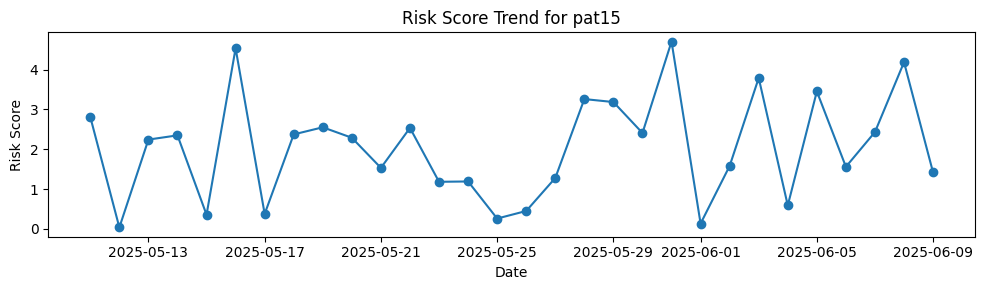

<Figure size 640x480 with 0 Axes>

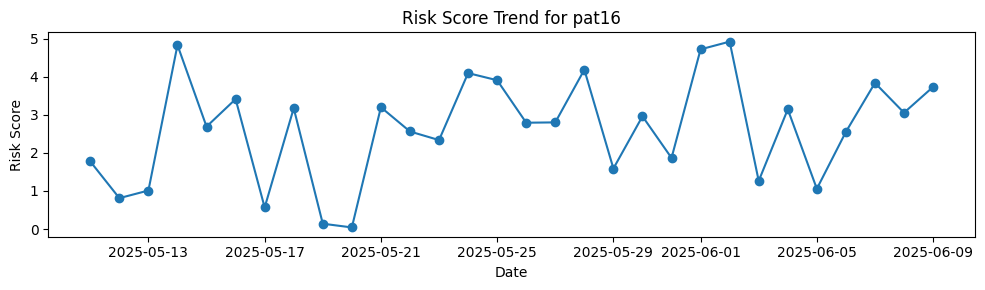

<Figure size 640x480 with 0 Axes>

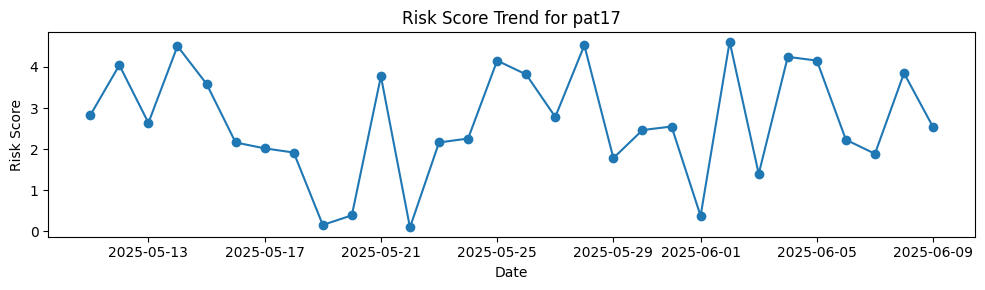

<Figure size 640x480 with 0 Axes>

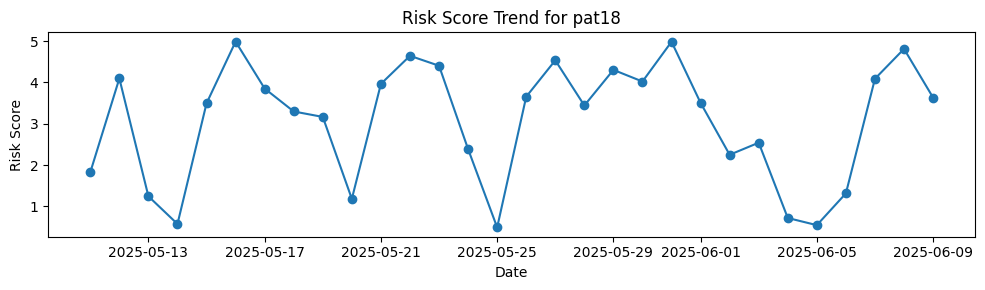

<Figure size 640x480 with 0 Axes>

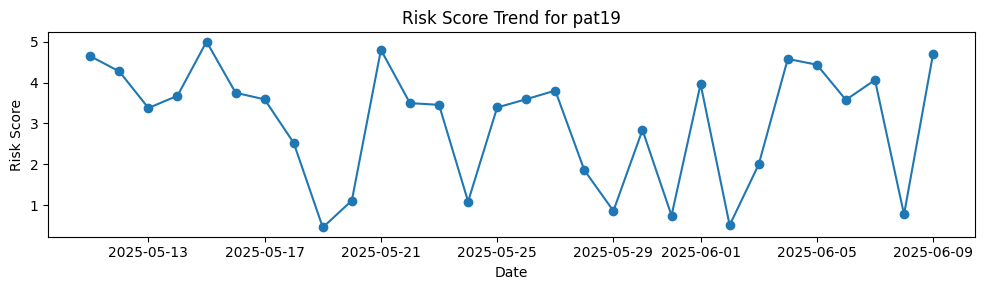

<Figure size 640x480 with 0 Axes>

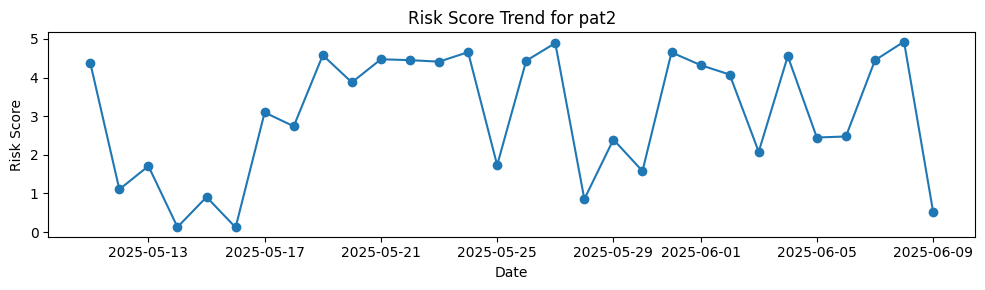

<Figure size 640x480 with 0 Axes>

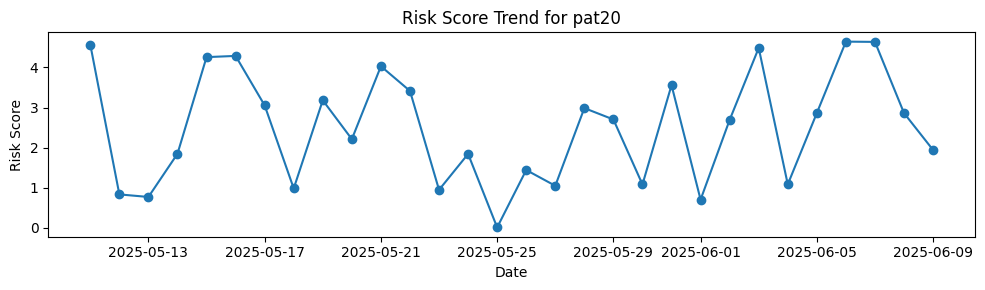

<Figure size 640x480 with 0 Axes>

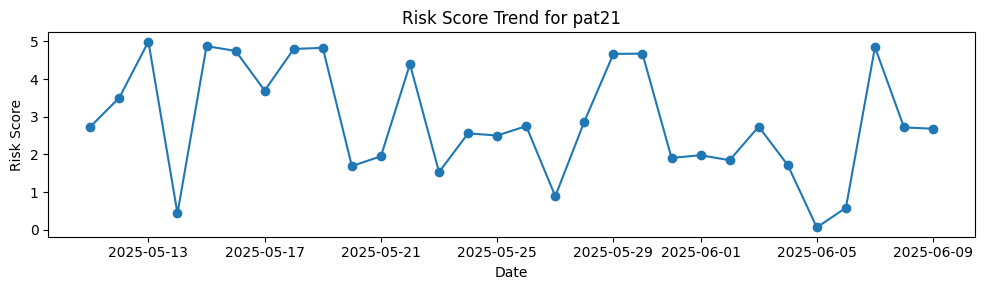

<Figure size 640x480 with 0 Axes>

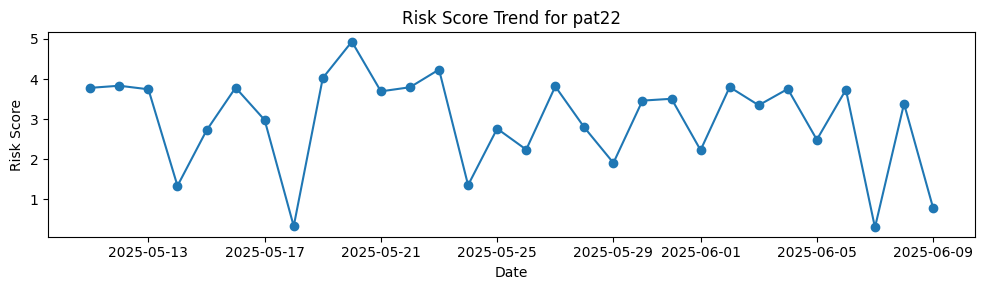

<Figure size 640x480 with 0 Axes>

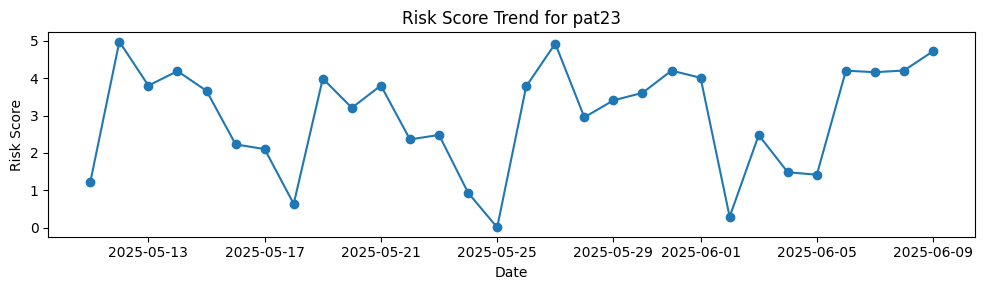

<Figure size 640x480 with 0 Axes>

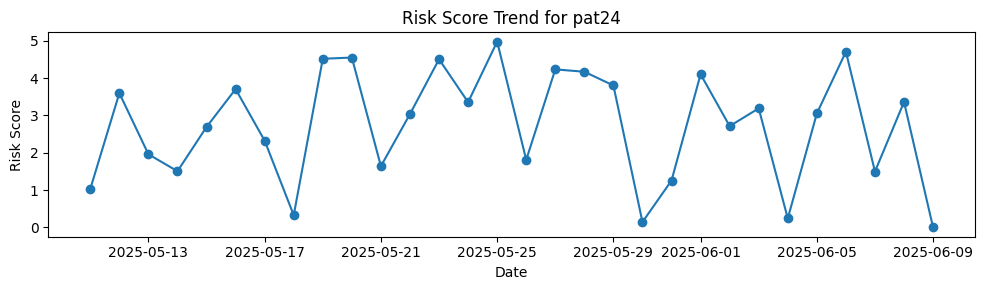

<Figure size 640x480 with 0 Axes>

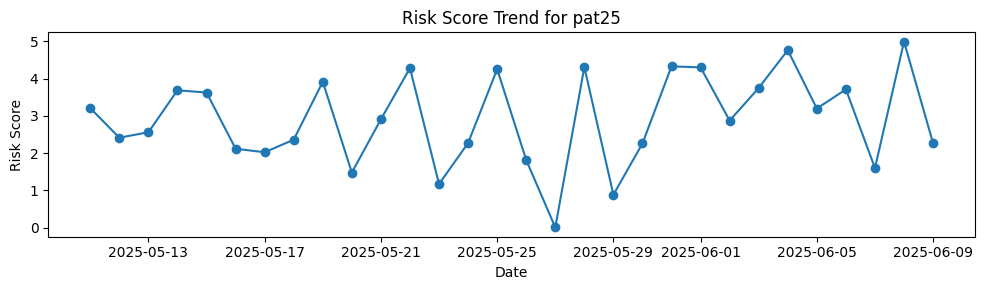

<Figure size 640x480 with 0 Axes>

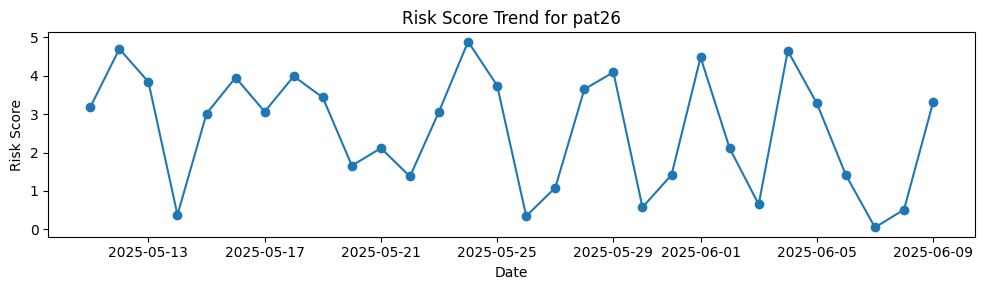

<Figure size 640x480 with 0 Axes>

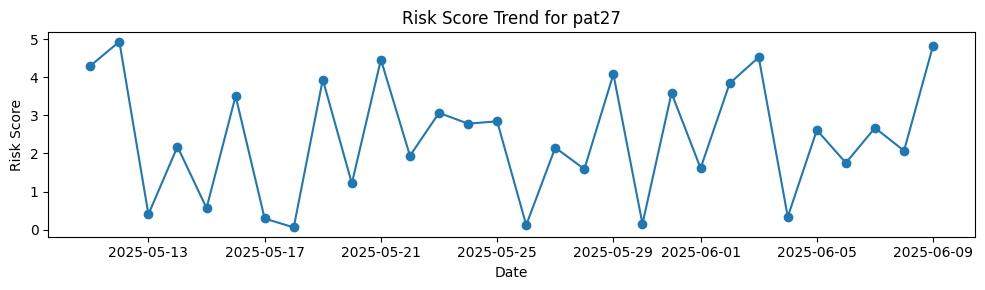

<Figure size 640x480 with 0 Axes>

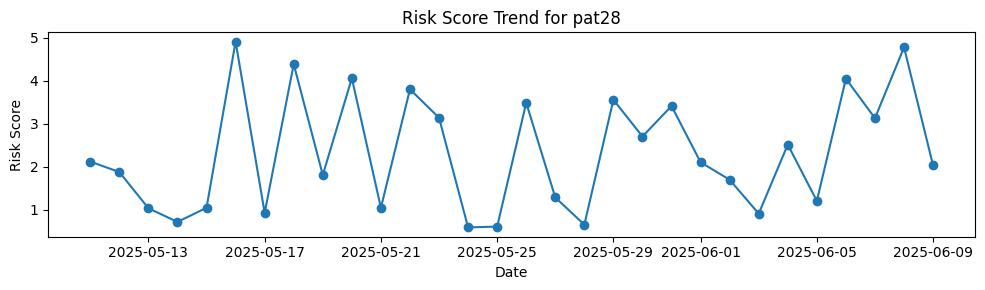

<Figure size 640x480 with 0 Axes>

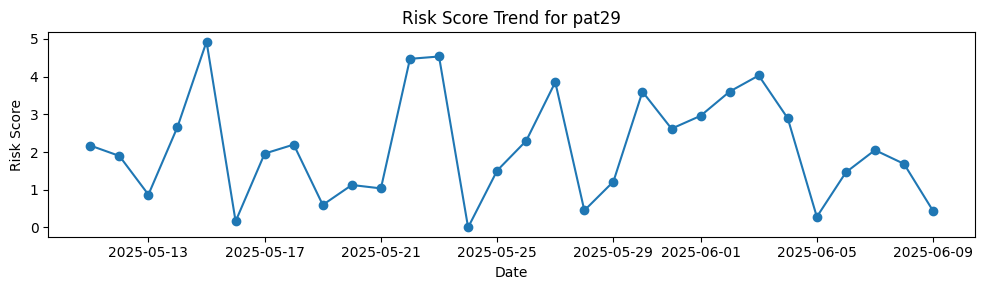

<Figure size 640x480 with 0 Axes>

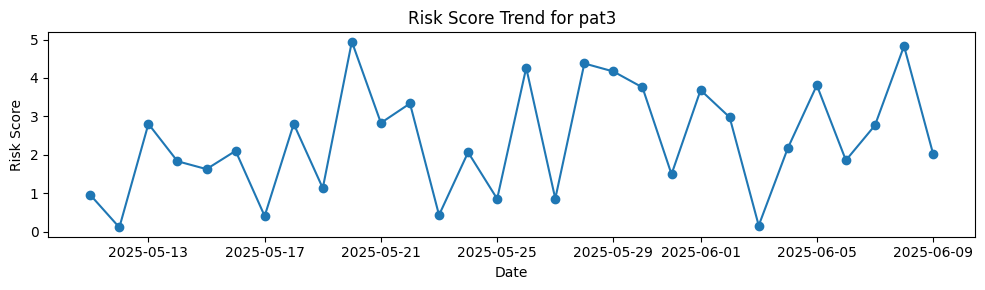

<Figure size 640x480 with 0 Axes>

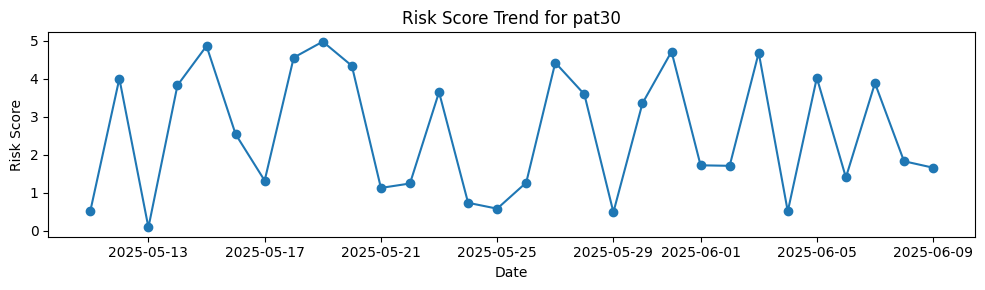

<Figure size 640x480 with 0 Axes>

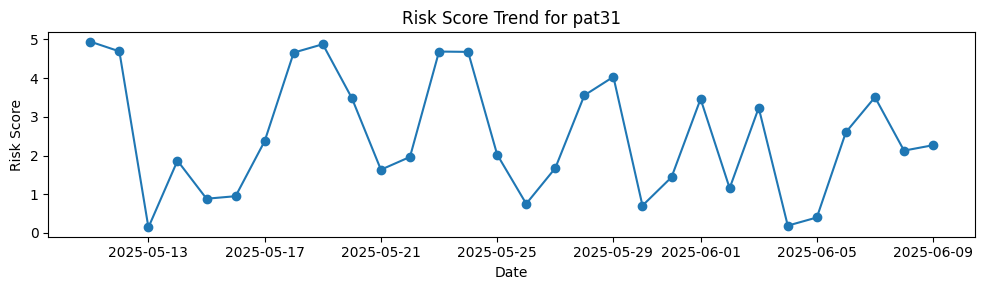

<Figure size 640x480 with 0 Axes>

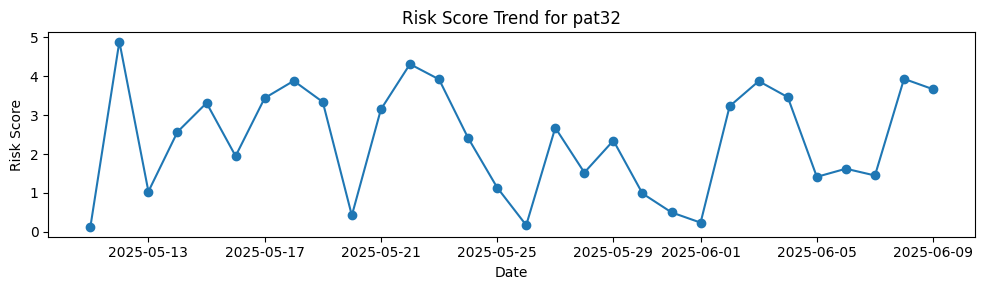

<Figure size 640x480 with 0 Axes>

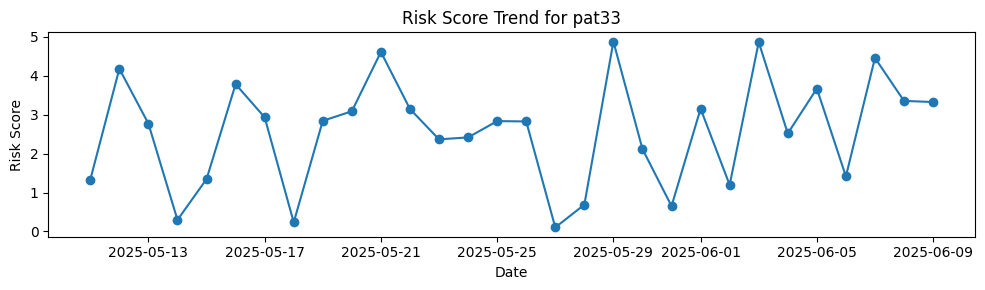

<Figure size 640x480 with 0 Axes>

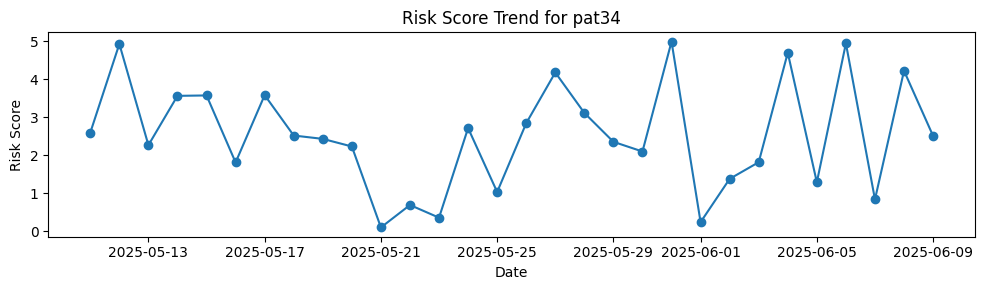

<Figure size 640x480 with 0 Axes>

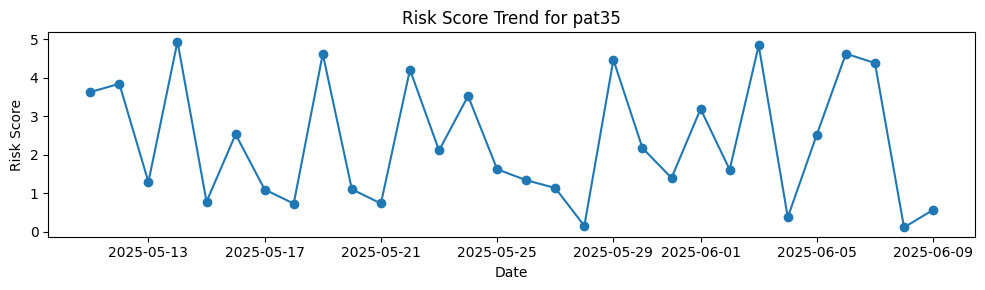

<Figure size 640x480 with 0 Axes>

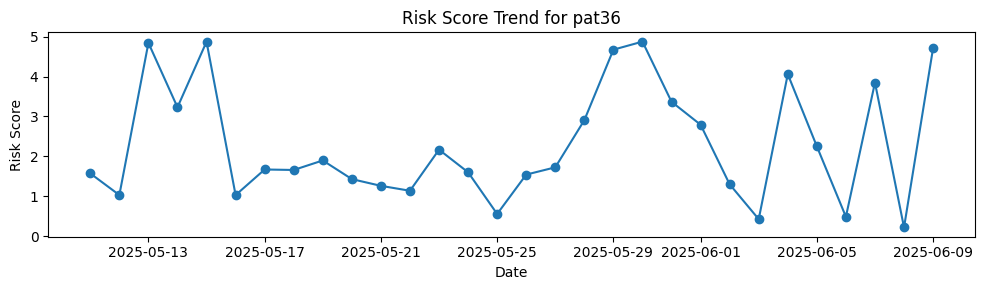

<Figure size 640x480 with 0 Axes>

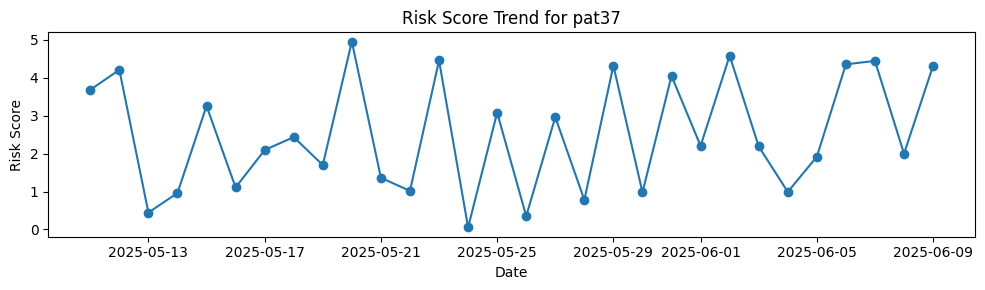

<Figure size 640x480 with 0 Axes>

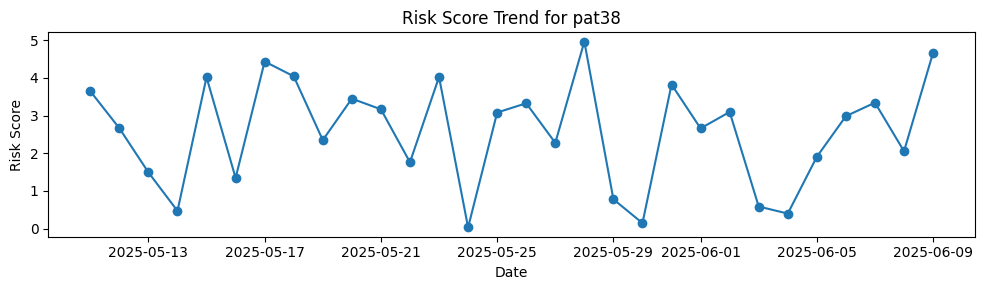

<Figure size 640x480 with 0 Axes>

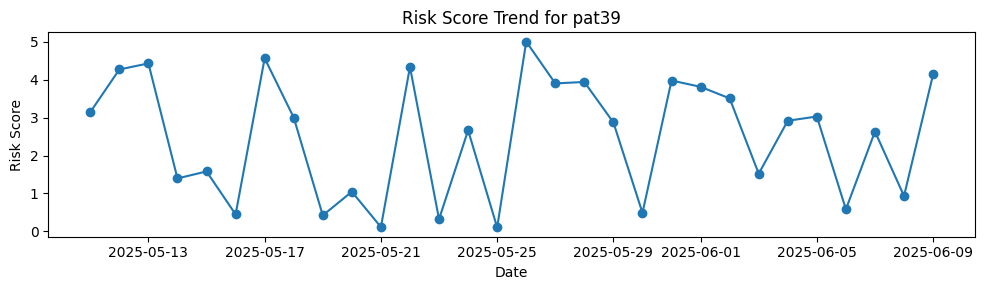

<Figure size 640x480 with 0 Axes>

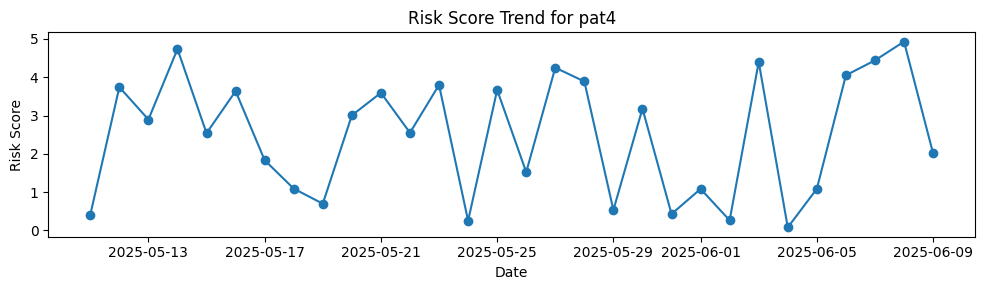

<Figure size 640x480 with 0 Axes>

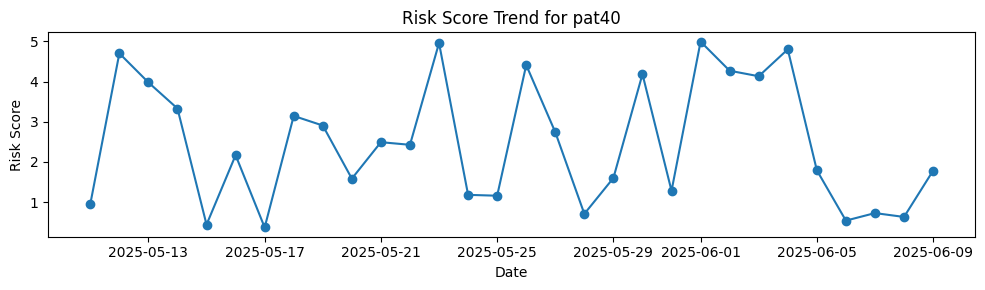

<Figure size 640x480 with 0 Axes>

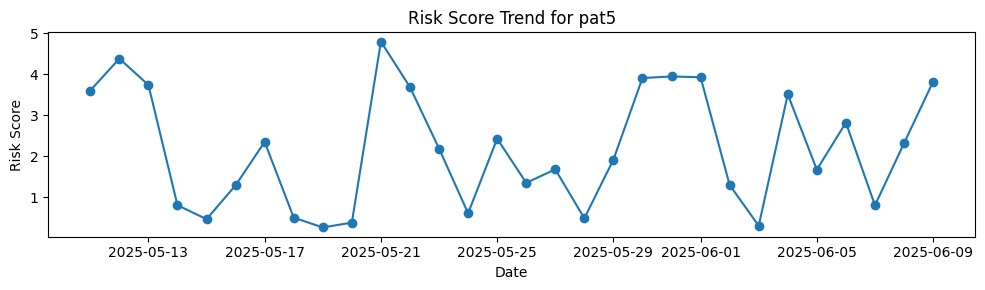

<Figure size 640x480 with 0 Axes>

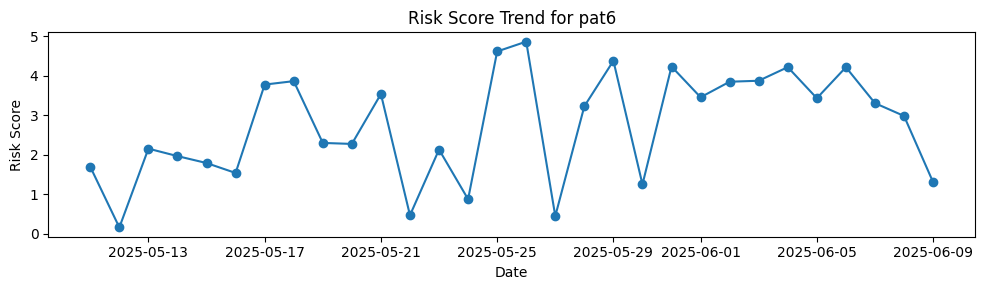

<Figure size 640x480 with 0 Axes>

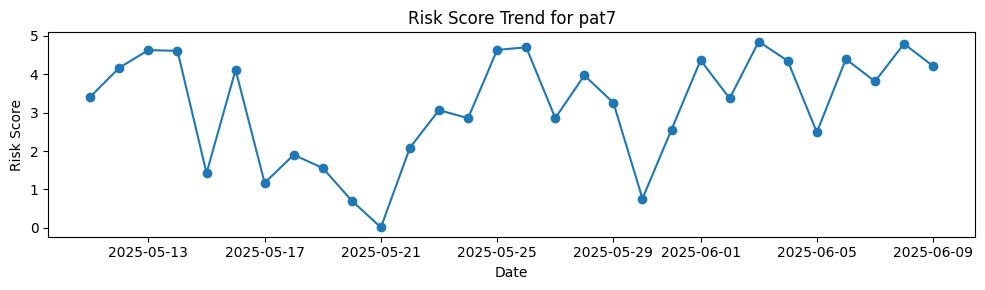

<Figure size 640x480 with 0 Axes>

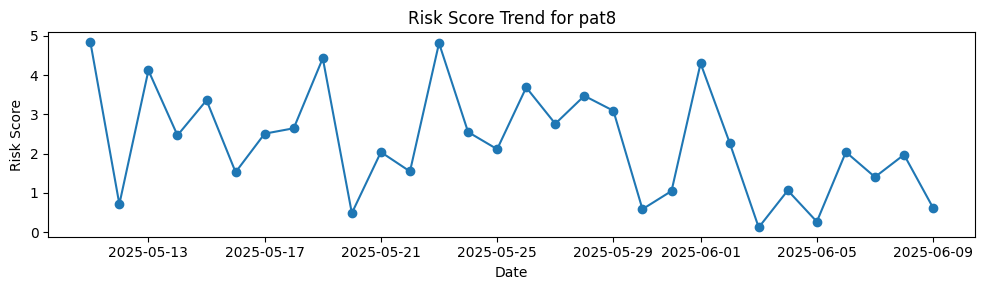

<Figure size 640x480 with 0 Axes>

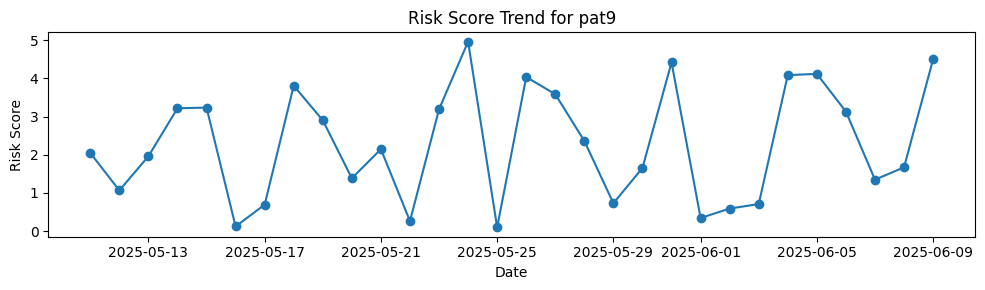

In [82]:

import pandas as pd
import numpy as np # Import numpy
from datetime import date, timedelta

# Create dummy data for demonstration
patients_list = features['patientId'].unique() # Use patient IDs from the features dataframe
num_days = 30 # Number of days for the trend

data = []
start_date = date.today() - timedelta(days=num_days)

for pid in patients_list:
    for i in range(num_days):
        current_date = start_date + timedelta(days=i)
        # Generate a dummy risk score (e.g., random or based on some simple logic)
        dummy_risk_score = np.random.rand() * 5 # Replace with your actual risk score calculation
        data.append({'date': current_date, 'patientId': pid, 'risk_score': dummy_risk_score})

risk_trend = pd.DataFrame(data)

# Ensure the 'date' column is in datetime format
risk_trend['date'] = pd.to_datetime(risk_trend['date'])

# Now, iterate and plot
for pid in risk_trend['patientId'].unique():
    plt.figure(figsize=(10,3))
    dfp = risk_trend[risk_trend['patientId']==pid]
    plt.plot(dfp['date'], dfp['risk_score'], marker='o')
    plt.title(f'Risk Score Trend for {pid}')
    plt.xlabel('Date')
    plt.ylabel('Risk Score')
    plt.tight_layout()
    plt.show()
    plt.savefig(f'risk_trend_{pid}.png')

<Figure size 640x480 with 0 Axes>

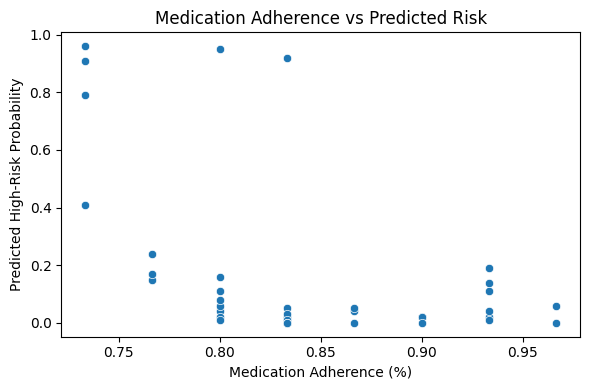

In [83]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=features['med_taken_pct'], y=features['risk_probability'])
plt.title('Medication Adherence vs Predicted Risk')
plt.xlabel('Medication Adherence (%)')
plt.ylabel('Predicted High-Risk Probability')
plt.tight_layout()
plt.show()
plt.savefig('adherence_vs_risk.png')


<Figure size 640x480 with 0 Axes>

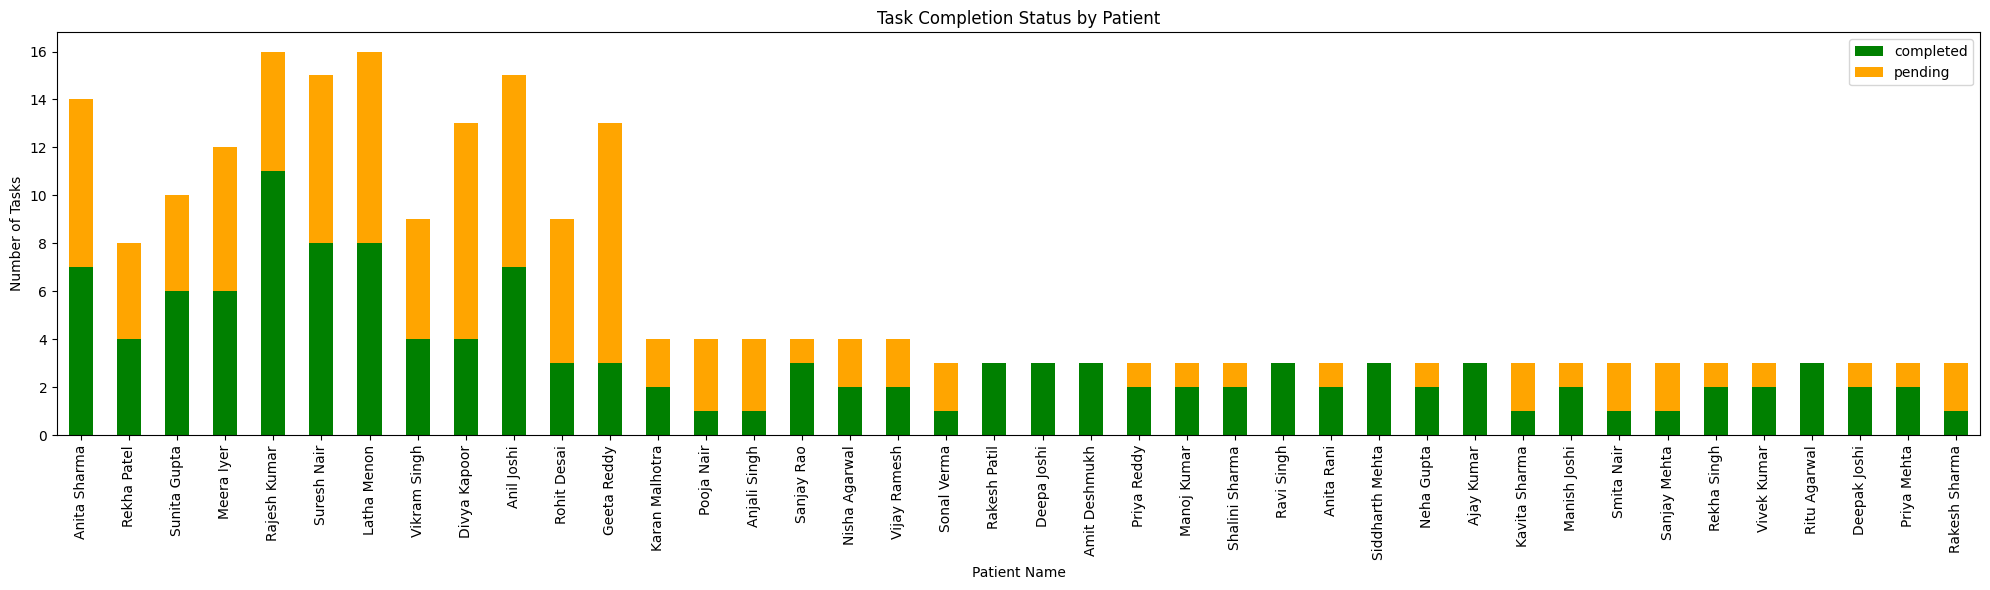

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
tasks = pd.read_csv('tasks (1).csv')
patients = pd.read_csv('patients.csv')

# Group by patient and status
task_counts = tasks.groupby(['assignedTo','status']).size().unstack(fill_value=0)

# Ensure both 'completed' and 'pending' columns exist
for col in ['completed', 'pending']:
    if col not in task_counts.columns:
        task_counts[col] = 0

# Merge with all patients to include those with zero tasks
all_patients = pd.DataFrame({'assignedTo': patients['patientId'], 'patient_name': patients['patient_name']})
task_counts = all_patients.merge(task_counts, left_on='assignedTo', right_index=True, how='left').fillna(0)

# Set patient name as index for plotting
task_counts = task_counts.set_index('patient_name')

# Plot
task_counts[['completed','pending']].plot(kind='bar', stacked=True, figsize=(20,6), color=['green','orange'])
plt.title('Task Completion Status by Patient')
plt.xlabel('Patient Name')
plt.ylabel('Number of Tasks')
plt.tight_layout()
plt.show()
plt.savefig('task_completion_status.png')


In [85]:

import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Simulate data for demonstration
dates = pd.date_range(start="2025-06-01", end="2025-06-30")
forecast_df = pd.DataFrame({
    'date': dates,
    'adherence': np.random.uniform(0.7, 1.0, len(dates)),
    'predicted_risk': np.random.uniform(0.1, 0.5, len(dates))
})

fig = go.Figure()
fig.add_trace(go.Scatter(x=forecast_df['date'], y=forecast_df['adherence'],
                         mode='lines+markers', name='Adherence'))
fig.add_trace(go.Scatter(x=forecast_df['date'], y=forecast_df['predicted_risk'],
                         mode='lines+markers', name='Predicted Risk', yaxis='y2'))

fig.update_layout(
    title="Adherence and Predicted Risk Over Time",
    xaxis_title="Date",
    yaxis=dict(title="Adherence"),
    yaxis2=dict(title="Predicted Risk", overlaying='y', side='right'),
    legend=dict(x=0.01, y=0.99)
)
fig.show()


In [90]:
import pandas as pd
import plotly.express as px
import numpy as np # numpy is already imported as np

# Example: Simulate predicted risk probabilities for patients
# Replace this with your actual risk score DataFrame if available
patients = pd.read_csv('patients.csv')
# Corrected: Use np.random.uniform directly instead of pd.np.random.uniform
patients['risk_probability'] = np.random.uniform(0, 1, size=len(patients))

fig = px.histogram(
    patients,
    x='risk_probability',
    nbins=20,
    title="Distribution of Predicted Patient Risk Probability",
    labels={'risk_probability': 'Predicted Risk Probability'},
    color='gender',
    barmode='overlay',
    opacity=0.7
)
fig.update_layout(xaxis_title='Predicted Risk Probability', yaxis_title='Number of Patients')
fig.show()

In [92]:
# Simulate adherence (replace with your actual metric if available)
patients['med_adherence'] = np.random.uniform(0.6, 1.0, size=len(patients))

fig = px.scatter(
    patients,
    x='med_adherence',
    y='risk_probability',
    color='gender',
    hover_data=['patient_name'],
    title="Medication Adherence vs Predicted Risk Probability"
)
fig.update_layout(xaxis_title='Medication Adherence', yaxis_title='Predicted Risk Probability')
fig.show()

In [93]:
top_patients = patients.sort_values('risk_probability', ascending=False).head(15)
fig = px.bar(
    top_patients,
    x='patient_name',
    y='risk_probability',
    color='risk_probability',
    color_continuous_scale='Reds',
    title="Top 15 Patients by Predicted Risk Probability"
)
fig.update_layout(xaxis_title='Patient', yaxis_title='Predicted Risk Probability')
fig.show()


In [94]:
import plotly.graph_objects as go

# Simulate feature importances (replace with your model's actual importances)
feature_names = ['missed_doses', 'severe_side_effects', 'pending_tasks', 'workout_adherence', 'diet_adherence']
importances = [0.35, 0.25, 0.15, 0.15, 0.10]

fig = go.Figure(go.Bar(
    x=importances,
    y=feature_names,
    orientation='h',
    marker=dict(color='indianred')
))
fig.update_layout(
    title="Feature Importances for Patient Risk Scoring",
    xaxis_title="Importance",
    yaxis_title="Feature"
)
fig.show()


In [96]:
import pandas as pd
import plotly.express as px
import numpy as np # Ensure numpy is imported

# Simulate drop-off risk
# Corrected: Use np.random.uniform instead of pd.np.random.uniform
patients['dropoff_risk'] = np.random.uniform(0, 1, size=len(patients))
top_dropoff = patients.sort_values('dropoff_risk', ascending=False).head(15)
fig = px.bar(
    top_dropoff,
    x='patient_name',
    y='dropoff_risk',
    color='dropoff_risk',
    color_continuous_scale='Blues',
    title="Top 15 Patients by Predicted Drop-off Risk"
)
fig.update_layout(xaxis_title='Patient', yaxis_title='Predicted Drop-off Risk')
fig.show()